# Dataset Loading

The Supply Chain dataset was loaded into a Pandas DataFrame.
The dataset contains information related to product sales, inventory levels,
warehouses, suppliers, pricing, promotions, and demand forecasting.


The initial dataset structure and dimensions are examined before performing
data-quality assessment and preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving P_3_supply_chain_dataset1.csv to P_3_supply_chain_dataset1.csv


In [ ]:
df = pd.read_csv("P_3_supply_chain_dataset1.csv")

df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 91250
Number of columns: 15


In [ ]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Columns in the dataset:

1. Date
2. SKU_ID
3. Warehouse_ID
4. Supplier_ID
5. Region
6. Units_Sold
7. Inventory_Level
8. Supplier_Lead_Time_Days
9. Reorder_Point
10. Order_Quantity
11. Unit_Cost
12. Unit_Price
13. Promotion_Flag
14. Stockout_Flag
15. Demand_Forecast


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast       

# Dataset Understanding and Data Quality Analysis

Before performing Preprocessing and Exploratory Analysis, the dataset is
examined to understand its structure and assess its data quality.


The analysis includes checking data types, missing values, duplicate records,
unique values, date coverage, descriptive statistics, constant variables,
and potential outliers.

### Dataset Structure

The structure of the dataset is examined to understand the number of
observations, variables, and the overall organization of the data.

In [ ]:
rows, columns = df.shape

print("Number of observations (rows):", rows)
print("Number of variables (columns):", columns)

Number of observations (rows): 91250
Number of variables (columns): 15


In [ ]:
structure = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum()
})

structure

,Column Name,Data Type,Non-Null Count
Date,Date,object,91250
SKU_ID,SKU_ID,object,91250
Warehouse_ID,Warehouse_ID,object,91250
Supplier_ID,Supplier_ID,object,91250
Region,Region,object,91250
Units_Sold,Units_Sold,int64,91250
Inventory_Level,Inventory_Level,int64,91250
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,int64,91250
Reorder_Point,Reorder_Point,int64,91250
Order_Quantity,Order_Quantity,int64,91250


**Observation:**  
The dataset contains 91,250 observations and 15 variables representing
product demand, inventory, supplier, warehouse, pricing, and promotional
information. The variable data types and non-null counts will be examined
further during the subsequent data-quality checks.

### Data Types

The data type of each variable is examined to determine whether the columns
are correctly represented as numerical, categorical, or date-based variables.
This helps identify variables that may require conversion during preprocessing.

In [ ]:
df.dtypes

,0
Date,object
SKU_ID,object
Warehouse_ID,object
Supplier_ID,object
Region,object
Units_Sold,int64
Inventory_Level,int64
Supplier_Lead_Time_Days,int64
Reorder_Point,int64
Order_Quantity,int64


In [ ]:
dtype_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_summary

,Column Name,Data Type
Date,Date,object
SKU_ID,SKU_ID,object
Warehouse_ID,Warehouse_ID,object
Supplier_ID,Supplier_ID,object
Region,Region,object
Units_Sold,Units_Sold,int64
Inventory_Level,Inventory_Level,int64
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,int64
Reorder_Point,Reorder_Point,int64
Order_Quantity,Order_Quantity,int64


**Observation:**  
The dataset contains numerical, categorical, binary, and date-related
variables. The `Date` variable is currently stored as an object data type
and will require conversion to a proper datetime format during preprocessing.
The categorical identifiers such as `SKU_ID`, `Warehouse_ID`, `Supplier_ID`,
and `Region` are represented as object variables, while the remaining
operational and sales-related variables are primarily numerical.

### Missing Value Analysis

Missing values are checked across all variables to determine whether any
observations require treatment before further analysis and preprocessing.

In [ ]:
# Summary of missing values

missing_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Column Name,Missing Values,Missing Percentage
Date,Date,0,0.0
SKU_ID,SKU_ID,0,0.0
Warehouse_ID,Warehouse_ID,0,0.0
Supplier_ID,Supplier_ID,0,0.0
Region,Region,0,0.0
Units_Sold,Units_Sold,0,0.0
Inventory_Level,Inventory_Level,0,0.0
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,0,0.0
Reorder_Point,Reorder_Point,0,0.0
Order_Quantity,Order_Quantity,0,0.0


In [ ]:
# Check whether the dataset contains any missing values

if df.isnull().sum().sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values are present in the dataset.")

No missing values found in the dataset.


**Observation:**  
No missing values were found in any of the 15 variables. Therefore, no
missing-value imputation or row removal is required at this stage.

### Duplicate Record Analysis

Duplicate records are checked to determine whether the dataset contains
repeated observations. Identifying duplicates is important because repeated
records can influence statistical analysis and machine learning results.

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate percentage: 0.0 %


**Observation:**  
The dataset contains no duplicate records. All 91,250 observations are unique,
so no duplicate rows need to be removed during the data-cleaning process.

### Unique Value Analysis

The number of unique values in each variable is examined to understand the
variety and structure of the dataset. This is particularly useful for
identifying categorical variables, binary variables, and variables with
limited variation.

In [ ]:
unique_values = pd.DataFrame({
    "Column Name": df.columns,
    "Unique Values": df.nunique()
})

unique_values

,Column Name,Unique Values
Date,Date,365
SKU_ID,SKU_ID,50
Warehouse_ID,Warehouse_ID,5
Supplier_ID,Supplier_ID,10
Region,Region,4
Units_Sold,Units_Sold,58
Inventory_Level,Inventory_Level,781
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,13
Reorder_Point,Reorder_Point,142
Order_Quantity,Order_Quantity,301


In [ ]:
# Display columns from lowest to highest number of unique values

unique_values.sort_values("Unique Values")

,Column Name,Unique Values
Stockout_Flag,Stockout_Flag,1
Promotion_Flag,Promotion_Flag,2
Region,Region,4
Warehouse_ID,Warehouse_ID,5
Supplier_ID,Supplier_ID,10
Supplier_Lead_Time_Days,Supplier_Lead_Time_Days,13
SKU_ID,SKU_ID,50
Units_Sold,Units_Sold,58
Reorder_Point,Reorder_Point,142
Unit_Price,Unit_Price,227


In [ ]:
# Check the unique values of the main Categorical Variables

categorical_columns = [
    "SKU_ID",
    "Warehouse_ID",
    "Supplier_ID",
    "Region"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


SKU_ID:
['SKU_1' 'SKU_2' 'SKU_3' 'SKU_4' 'SKU_5' 'SKU_6' 'SKU_7' 'SKU_8' 'SKU_9'
 'SKU_10' 'SKU_11' 'SKU_12' 'SKU_13' 'SKU_14' 'SKU_15' 'SKU_16' 'SKU_17'
 'SKU_18' 'SKU_19' 'SKU_20' 'SKU_21' 'SKU_22' 'SKU_23' 'SKU_24' 'SKU_25'
 'SKU_26' 'SKU_27' 'SKU_28' 'SKU_29' 'SKU_30' 'SKU_31' 'SKU_32' 'SKU_33'
 'SKU_34' 'SKU_35' 'SKU_36' 'SKU_37' 'SKU_38' 'SKU_39' 'SKU_40' 'SKU_41'
 'SKU_42' 'SKU_43' 'SKU_44' 'SKU_45' 'SKU_46' 'SKU_47' 'SKU_48' 'SKU_49'
 'SKU_50']

Warehouse_ID:
['WH_1' 'WH_2' 'WH_3' 'WH_4' 'WH_5']

Supplier_ID:
['SUP_8' 'SUP_5' 'SUP_9' 'SUP_2' 'SUP_7' 'SUP_10' 'SUP_6' 'SUP_4' 'SUP_3'
 'SUP_1']

Region:
['West' 'North' 'South' 'East']


In [ ]:
# Check the values present in the binary variables

print("Promotion_Flag values:", df["Promotion_Flag"].unique())
print("Stockout_Flag values:", df["Stockout_Flag"].unique())

Promotion_Flag values: [0 1]
Stockout_Flag values: [0]


**Observation:**  
The dataset contains 50 unique SKUs, 5 warehouses, 10 suppliers, and 4 regions.
The `Promotion_Flag` variable contains two values, representing its binary
nature. In contrast, `Stockout_Flag` contains only one unique value, indicating
that there is no variation in this variable in the provided dataset.

The date variable contains 365 unique dates, covering approximately one year
of observations. The remaining numerical variables contain varying numbers
of unique values.

### Date Range Analysis

The date variable is examined to determine the time period covered by the
dataset and the number of unique dates available for analysis. This is
important for understanding the temporal coverage of the data and for
designing the time-based train-test split used later in the study.

In [ ]:
# Convert the Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date data type:", df["Date"].dtype)

Date data type: datetime64[ns]


In [ ]:
# Determine the date range and number of unique dates

start_date = df["Date"].min()
end_date = df["Date"].max()
unique_dates = df["Date"].nunique()

print("Start date:", start_date.date())
print("End date:", end_date.date())
print("Number of unique dates:", unique_dates)

Start date: 2024-01-01
End date: 2024-12-30
Number of unique dates: 365


In [ ]:
# Count the number of observations recorded for each date

daily_counts = df.groupby("Date").size()

print("Minimum observations on a date:", daily_counts.min())
print("Maximum observations on a date:", daily_counts.max())
print("Average observations per date:", round(daily_counts.mean(), 2))

Minimum observations on a date: 250
Maximum observations on a date: 250
Average observations per date: 250.0


**Observation:**  
The dataset covers the period from 1 January 2024 to 30 December 2024,
with 365 unique dates. Each date contains 250 observations, corresponding
to the combinations of 50 SKUs and 5 warehouses. This provides a consistent
daily structure across the dataset and supports the use of chronological
data splitting for next-day demand prediction.

### Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables in the
dataset. Measures such as mean, standard deviation, minimum, maximum, and
quartiles provide an initial understanding of the distribution and range of
the supply-chain variables.

In [ ]:
df.describe()

,Date,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,2024-07-01 00:00:00,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
min,2024-01-01 00:00:00,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,2024-04-01 00:00:00,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,2024-07-01 00:00:00,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,2024-09-30 00:00:00,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,2024-12-30 00:00:00,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000
std,NaN,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955


In [ ]:
# Round numerical values for better readability

df.describe().round(2)

,Date,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.0,91250.0,91250.00
mean,2024-07-01 00:00:00,20.05,471.52,7.98,300.07,19.27,12.20,18.26,0.1,0.0,20.08
min,2024-01-01 00:00:00,0.00,168.00,2.00,201.00,0.00,5.02,6.95,0.0,0.0,0.00
25%,2024-04-01 00:00:00,13.00,370.00,4.00,252.00,0.00,8.18,12.00,0.0,0.0,12.95
50%,2024-07-01 00:00:00,20.00,461.00,8.00,300.00,0.00,11.99,18.18,0.0,0.0,19.95
75%,2024-09-30 00:00:00,27.00,564.00,11.00,346.00,0.00,16.32,23.39,0.0,0.0,26.93
max,2024-12-30 00:00:00,59.00,990.00,14.00,398.00,499.00,19.76,35.10,1.0,0.0,61.42
std,NaN,9.07,133.49,3.91,54.88,82.34,4.57,7.12,0.3,0.0,9.50


In [ ]:
# Descriptive statistics for numerical variables

numeric_summary = df.select_dtypes(include=np.number).describe().round(2)

numeric_summary

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.00,91250.0,91250.0,91250.00
mean,20.05,471.52,7.98,300.07,19.27,12.20,18.26,0.1,0.0,20.08
std,9.07,133.49,3.91,54.88,82.34,4.57,7.12,0.3,0.0,9.50
min,0.00,168.00,2.00,201.00,0.00,5.02,6.95,0.0,0.0,0.00
25%,13.00,370.00,4.00,252.00,0.00,8.18,12.00,0.0,0.0,12.95
50%,20.00,461.00,8.00,300.00,0.00,11.99,18.18,0.0,0.0,19.95
75%,27.00,564.00,11.00,346.00,0.00,16.32,23.39,0.0,0.0,26.93
max,59.00,990.00,14.00,398.00,499.00,19.76,35.10,1.0,0.0,61.42


**Observation:**  
The descriptive statistics show that `Units_Sold` has a mean of 20.05 units
with values ranging from 0 to 59 units. `Inventory_Level` has a mean of
471.52 units and ranges from 168 to 990 units. The average supplier lead
time is 7.98 days, with values ranging from 2 to 14 days.


The average reorder point is 300.07 units, while order quantities range from
0 to 499 units. `Unit_Cost` ranges from 5.02 to 19.76, and `Unit_Price`
ranges from 6.95 to 35.10. The mean promotion flag is approximately 0.10,
indicating that promotional records represent a relatively small proportion
of the observations.


The `Order_Quantity` variable shows a notable concentration of values at
zero, as its 25th, 50th, and 75th percentiles are all zero despite having a
maximum value of 499. This distribution will be examined further during
exploratory data analysis.

### Constant Variable Analysis

Constant variables are identified by checking the number of unique values in
each column. Variables containing only one unique value provide no variation
across observations and therefore do not provide useful information for
machine learning prediction.

In [ ]:
# Identify columns containing only one unique value

constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

print("Constant columns:", constant_columns)

Constant columns: ['Stockout_Flag']


In [ ]:
# Display the unique value of each constant column

for column in constant_columns:
    print(f"{column}: {df[column].unique()}")

Stockout_Flag: [0]


**Observation:**  
The analysis identified `Stockout_Flag` as a constant variable because it
contains only the value 0 across all observations. Since the variable has no
variation, it cannot contribute useful predictive information to the machine
learning models. It will therefore be excluded from the feature set during
the preprocessing and feature-selection stage.

### Outlier Analysis

Potential outliers in the numerical variables are examined to identify
unusually high or low observations. The Interquartile Range (IQR) method is
used as an initial statistical screening technique.

Identified observations are not automatically removed, as extreme values may
represent legitimate supply-chain conditions. Their relevance will be
considered during exploratory data analysis and preprocessing.

In [ ]:
# Select numerical variables for outlier analysis

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical variables:")
print(list(numeric_columns))

Numerical variables:
['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']


In [ ]:
# Calculate potential outliers using the IQR method

outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) |
                     (df[column] > upper_bound)).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.round(2)

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Units_Sold,13.00,27.00,-8.00,48.00,110,0.12
1,Inventory_Level,370.00,564.00,79.00,855.00,199,0.22
2,Supplier_Lead_Time_Days,4.00,11.00,-6.50,21.50,0,0.00
3,Reorder_Point,252.00,346.00,111.00,487.00,0,0.00
4,Order_Quantity,0.00,0.00,0.00,0.00,5027,5.51
5,Unit_Cost,8.18,16.32,-4.03,28.53,0,0.00
6,Unit_Price,12.00,23.39,-5.09,40.48,0,0.00
7,Promotion_Flag,0.00,0.00,0.00,0.00,9270,10.16
8,Stockout_Flag,0.00,0.00,0.00,0.00,0,0.00
9,Demand_Forecast,12.95,26.93,-8.02,47.90,185,0.20


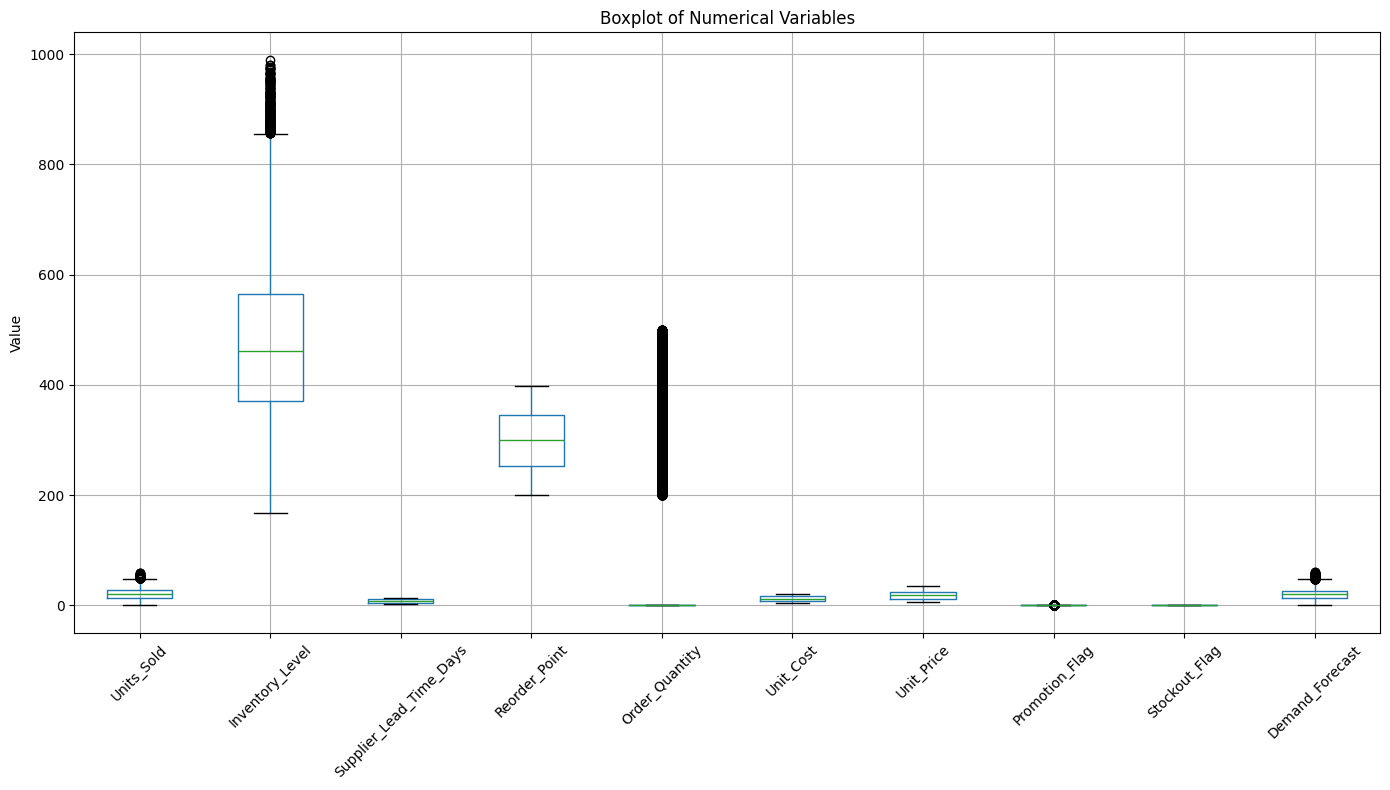

In [ ]:
# Visualize numerical variables using boxplots

plt.figure(figsize=(14, 8))

df[numeric_columns].boxplot(rot=45)

plt.title("Boxplot of Numerical Variables")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

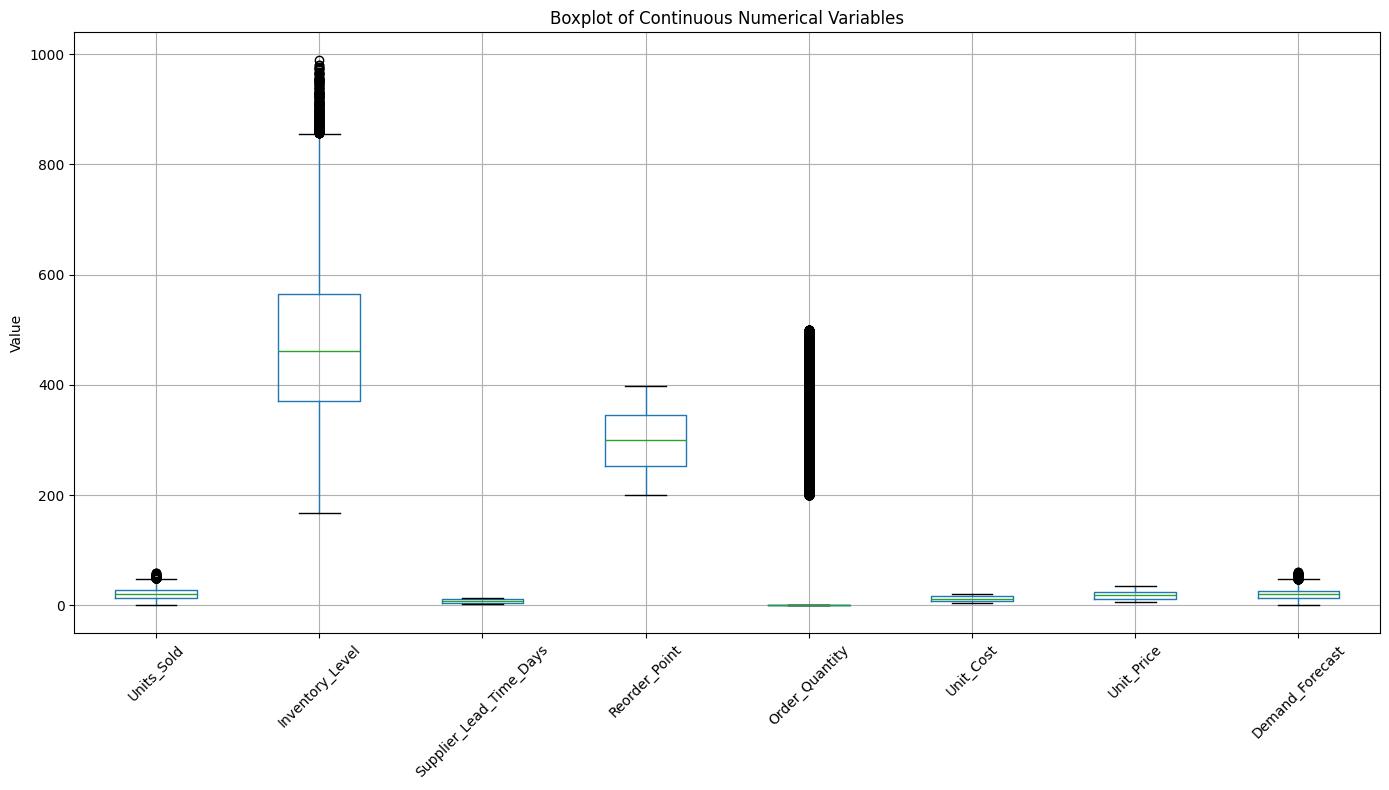

In [ ]:
# Select continuous numerical variables for boxplot analysis

continuous_columns = [
    "Units_Sold",
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Demand_Forecast"
]

plt.figure(figsize=(14, 8))

df[continuous_columns].boxplot(rot=45)

plt.title("Boxplot of Continuous Numerical Variables")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

**Observation:**  
The IQR analysis identified potential outliers in `Units_Sold`,
`Inventory_Level`, `Order_Quantity`, `Promotion_Flag`, and
`Demand_Forecast`.


`Units_Sold` has 110 potential outliers (0.12% of observations), while
`Inventory_Level` has 199 potential outliers (0.22%). `Demand_Forecast`
has 185 potential outliers (0.20%).


`Order_Quantity` shows 5,027 potential outliers (5.51%). This is mainly
because the first, second, and third quartiles are all zero, resulting in
an IQR of zero. Therefore, these values should not be automatically
considered erroneous and will be examined based on their distribution and
business meaning.


Similarly, `Promotion_Flag` has 9,270 observations flagged by the IQR
method. Since this is a binary variable, the IQR method is not appropriate
for identifying outliers in this column. These observations represent the
presence of promotions rather than data errors.


No potential outliers were identified by the IQR method for
`Supplier_Lead_Time_Days`, `Reorder_Point`, `Unit_Cost`, or `Unit_Price`.


Based on this analysis, no observations are removed solely because they
were identified as statistical outliers. Further investigation will be
performed during exploratory data analysis.

### Overall Data Quality Findings

The dataset was systematically examined for structural and data-quality
issues before preprocessing. The dataset contains 91,250 observations and
15 variables covering the period from January 2024 to December 2024.


No missing values or duplicate records were identified. The dataset contains
50 SKUs, 5 warehouses, 10 suppliers, and 4 regions, with 365 unique dates.
The `Date` variable was converted from object format to datetime format for
subsequent temporal analysis.


The analysis also identified `Stockout_Flag` as a constant variable containing
only the value 0. Since it provides no variation, it will be excluded from
the machine learning feature set.


The IQR analysis identified potential statistical outliers in some numerical
variables. However, these observations were not automatically removed because
extreme values may represent legitimate supply-chain conditions. In particular, the distribution of `Order_Quantity` requires careful
interpretation because a large proportion of its observations are zero.


The existing `Demand_Forecast` variable will also be carefully evaluated
before model development because the objective of this study is to predict
future demand using information available before the prediction period.
Variables that could introduce target leakage will not be used as predictive
features.


Overall, the dataset is structurally complete and contains no missing or
duplicate records. The identified issues will be addressed through
appropriate preprocessing, feature selection, and feature engineering rather
than indiscriminate removal of observations.

In [ ]:
quality_summary = pd.DataFrame({
    "Check": [
        "Number of rows",
        "Number of columns",
        "Missing values",
        "Duplicate rows",
        "Unique dates",
        "Unique SKUs",
        "Unique warehouses",
        "Unique suppliers",
        "Unique regions",
        "Constant columns"
    ],
    "Result": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Date"].nunique(),
        df["SKU_ID"].nunique(),
        df["Warehouse_ID"].nunique(),
        df["Supplier_ID"].nunique(),
        df["Region"].nunique(),
        ", ".join(constant_columns) if constant_columns else "None"
    ]
})

quality_summary

,Check,Result
0,Number of rows,91250
1,Number of columns,15
2,Missing values,0
3,Duplicate rows,0
4,Unique dates,365
5,Unique SKUs,50
6,Unique warehouses,5
7,Unique suppliers,10
8,Unique regions,4
9,Constant columns,Stockout_Flag


# Data Preprocessing

Data preprocessing is performed to prepare the dataset for machine learning
while preserving the temporal structure of the supply-chain data.

The preprocessing stage includes data cleaning, date and categorical variable
handling, feature engineering, target construction, and preparation of the
training and testing datasets.

Since the objective is to predict next-day product demand, all predictive
features must represent information that would be available before the target
day. This helps prevent data leakage and ensures that the resulting model
better represents a realistic demand forecasting scenario.

### Data Cleaning

The dataset is cleaned based on the findings from the data-quality analysis.
Missing values and duplicate records were not present in the original dataset.
Therefore, no imputation or duplicate-row removal is required.


The constant `Stockout_Flag` variable is excluded because it contains no
variation across the observations. The existing `Demand_Forecast` variable
is also excluded from predictive modeling because it is highly related to
actual demand and could introduce target leakage when predicting future sales.

In [ ]:
# Create a copy of the original dataset for preprocessing

df_processed = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_processed.shape)

Original dataset shape: (91250, 15)
Working dataset shape: (91250, 15)


In [ ]:
# Remove variables that should not be used for prediction

df_processed = df_processed.drop(
    columns=["Stockout_Flag", "Demand_Forecast"]
)

print("Columns after removing unsuitable variables:")
print(df_processed.columns.tolist())

Columns after removing unsuitable variables:
['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag']


**Observation:**  
The preprocessing dataset retains 13 variables after excluding
`Stockout_Flag` and `Demand_Forecast`. `Stockout_Flag` was removed because it
was constant throughout the dataset, while `Demand_Forecast` was excluded
from the predictive feature set to reduce the risk of target leakage.

No rows were removed because the dataset contained neither missing values nor
duplicate records.

### Target Variable Construction

The target variable is constructed to represent next-day product demand.
For each SKU-Warehouse combination, the `Units_Sold` value from the following
day is assigned as the target for the current observation.

This allows the machine learning models to learn from information available
on the current day and predict demand for the next day.

The target is created separately for each SKU-Warehouse combination to
preserve the individual demand patterns of each product and warehouse.

In [ ]:
# Sort observations by SKU, warehouse, and date

df_processed = df_processed.sort_values(
    by=["SKU_ID", "Warehouse_ID", "Date"]
).reset_index(drop=True)

df_processed.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0


In [ ]:
# Create the next-day demand target for each SKU-Warehouse combination

df_processed["Next_Day_Units_Sold"] = (
    df_processed
    .groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"]
    .shift(-1)
)

df_processed.head(10)

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Next_Day_Units_Sold
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,17.0
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,35.0
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,24.0
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,21.0
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,18.0
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18,477,14,379,0,13.95,20.48,0,19.0
6,2024-01-07,SKU_1,WH_1,SUP_8,North,19,458,14,379,0,13.95,20.48,0,23.0
7,2024-01-08,SKU_1,WH_1,SUP_8,North,23,435,14,379,0,13.95,20.48,1,25.0
8,2024-01-09,SKU_1,WH_1,SUP_8,West,25,410,14,379,0,13.95,20.48,0,25.0
9,2024-01-10,SKU_1,WH_1,SUP_8,South,25,385,14,379,0,13.95,20.48,0,23.0


In [ ]:
# Check missing values created in the target variable

print(
    "Missing values in Next_Day_Units_Sold:",
    df_processed["Next_Day_Units_Sold"].isnull().sum()
)

Missing values in Next_Day_Units_Sold: 250


In [ ]:
# Remove observations where next-day demand is unavailable

df_processed = df_processed.dropna(
    subset=["Next_Day_Units_Sold"]
).reset_index(drop=True)

print("Dataset shape after target construction:", df_processed.shape)

Dataset shape after target construction: (91000, 14)


**Observation:**  
The target variable `Next_Day_Units_Sold` was created by shifting `Units_Sold`
by one day within each SKU-Warehouse combination. This ensures that the model
will predict future demand rather than the demand of the same observation.


The final observation for each of the 250 SKU-Warehouse combinations does not
have a corresponding next-day demand value and was therefore removed. This
resulted in 91,000 observations and 14 variables available for subsequent
feature engineering and model development.

### Historical Demand Feature Engineering

Historical demand features are created from previous `Units_Sold` values to
capture short-term and weekly demand patterns.


Lag features represent demand from previous days, while rolling mean features
capture the recent average demand. These features are calculated separately
for each SKU-Warehouse combination to preserve product-specific and
warehouse-specific demand patterns.


Only past observations are used when calculating these features to prevent
future information from being introduced into the prediction process.

In [ ]:
# Create historical demand lag features for each SKU-Warehouse combination

grouped_sales = df_processed.groupby(
    ["SKU_ID", "Warehouse_ID"]
)["Units_Sold"]

df_processed["lag_1"] = grouped_sales.shift(1)
df_processed["lag_7"] = grouped_sales.shift(7)
df_processed["lag_14"] = grouped_sales.shift(14)

df_processed.head(15)

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Next_Day_Units_Sold,lag_1,lag_7,lag_14
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,17.0,NaN,NaN,NaN
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,35.0,10.0,NaN,NaN
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,24.0,17.0,NaN,NaN
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,21.0,35.0,NaN,NaN
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,18.0,24.0,NaN,NaN
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18,477,14,379,0,13.95,20.48,0,19.0,21.0,NaN,NaN
6,2024-01-07,SKU_1,WH_1,SUP_8,North,19,458,14,379,0,13.95,20.48,0,23.0,18.0,NaN,NaN
7,2024-01-08,SKU_1,WH_1,SUP_8,North,23,435,14,379,0,13.95,20.48,1,25.0,19.0,10.0,NaN
8,2024-01-09,SKU_1,WH_1,SUP_8,West,25,410,14,379,0,13.95,20.48,0,25.0,23.0,17.0,NaN
9,2024-01-10,SKU_1,WH_1,SUP_8,South,25,385,14,379,0,13.95,20.48,0,23.0,25.0,35.0,NaN


In [ ]:
# Create rolling average demand features using only previous observations

df_processed["rolling_mean_7"] = (
    df_processed.groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

df_processed["rolling_mean_14"] = (
    df_processed.groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=14).mean())
)

df_processed.head(20)

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Next_Day_Units_Sold,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,17.0,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,35.0,10.0,NaN,NaN,NaN,NaN
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,24.0,17.0,NaN,NaN,NaN,NaN
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,21.0,35.0,NaN,NaN,NaN,NaN
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,18.0,24.0,NaN,NaN,NaN,NaN
5,2024-01-06,SKU_1,WH_1,SUP_8,East,18,477,14,379,0,13.95,20.48,0,19.0,21.0,NaN,NaN,NaN,NaN
6,2024-01-07,SKU_1,WH_1,SUP_8,North,19,458,14,379,0,13.95,20.48,0,23.0,18.0,NaN,NaN,NaN,NaN
7,2024-01-08,SKU_1,WH_1,SUP_8,North,23,435,14,379,0,13.95,20.48,1,25.0,19.0,10.0,NaN,20.571429,NaN
8,2024-01-09,SKU_1,WH_1,SUP_8,West,25,410,14,379,0,13.95,20.48,0,25.0,23.0,17.0,NaN,22.428571,NaN
9,2024-01-10,SKU_1,WH_1,SUP_8,South,25,385,14,379,0,13.95,20.48,0,23.0,25.0,35.0,NaN,23.571429,NaN


In [ ]:
# Check missing values created by historical features

historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]

df_processed[historical_features].isnull().sum()

,0
lag_1,250
lag_7,1750
lag_14,3500
rolling_mean_7,1750
rolling_mean_14,3500


In [ ]:
# Remove observations that do not have sufficient historical demand information

df_processed = df_processed.dropna(
    subset=historical_features
).reset_index(drop=True)

print("Dataset shape after historical feature engineering:",
      df_processed.shape)

Dataset shape after historical feature engineering: (87500, 19)


**Observation:**  
Historical demand features were created separately for each SKU-Warehouse
combination. The lag features capture demand from 1, 7, and 14 days earlier,
while the 7-day and 14-day rolling means capture recent demand patterns.


The rolling features were calculated after shifting the sales series by one
day, ensuring that the demand being predicted is not included in the
historical averages. Observations without sufficient historical information
were removed because the 14-day lag and rolling window require prior demand
values.

### Temporal Feature Engineering

Temporal features are extracted from the `Date` variable to capture
time-related patterns in product demand. The features include day of the
week, month, quarter, week of the year, and day of the year.

These features provide the machine learning models with calendar information
that may help identify recurring demand patterns.

In [ ]:
df_processed["day_of_week"] = df_processed["Date"].dt.dayofweek
df_processed["month"] = df_processed["Date"].dt.month
df_processed["quarter"] = df_processed["Date"].dt.quarter
df_processed["week_of_year"] = df_processed["Date"].dt.isocalendar().week.astype(int)
df_processed["day_of_year"] = df_processed["Date"].dt.dayofyear

df_processed.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,...,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,day_of_week,month,quarter,week_of_year,day_of_year
0,2024-01-15,SKU_1,WH_1,SUP_8,North,19,733,14,379,0,...,26.0,23.0,10.0,25.142857,22.857143,0,1,1,3,15
1,2024-01-16,SKU_1,WH_1,SUP_8,West,19,714,14,379,0,...,19.0,25.0,17.0,24.571429,23.500000,1,1,1,3,16
2,2024-01-17,SKU_1,WH_1,SUP_8,East,26,688,14,379,0,...,19.0,25.0,35.0,23.714286,23.642857,2,1,1,3,17
3,2024-01-18,SKU_1,WH_1,SUP_8,North,22,666,14,379,0,...,26.0,23.0,24.0,23.857143,23.000000,3,1,1,3,18
4,2024-01-19,SKU_1,WH_1,SUP_8,North,28,638,14,379,0,...,22.0,29.0,21.0,23.714286,22.857143,4,1,1,3,19


In [ ]:
# Display the temporal features

temporal_features = [
    "day_of_week",
    "month",
    "quarter",
    "week_of_year",
    "day_of_year"
]

df_processed[temporal_features].head(10)

,day_of_week,month,quarter,week_of_year,day_of_year
0,0,1,1,3,15
1,1,1,1,3,16
2,2,1,1,3,17
3,3,1,1,3,18
4,4,1,1,3,19
5,5,1,1,3,20
6,6,1,1,3,21
7,0,1,1,4,22
8,1,1,1,4,23
9,2,1,1,4,24


In [ ]:
# Check the range of each temporal feature

df_processed[temporal_features].describe().round(2)

,day_of_week,month,quarter,week_of_year,day_of_year
count,87500.0,87500.00,87500.00,87500.00,87500.00
mean,3.0,6.70,2.56,27.50,189.50
std,2.0,3.32,1.10,14.43,101.04
min,0.0,1.00,1.00,3.00,15.00
25%,1.0,4.00,2.00,15.00,102.00
50%,3.0,7.00,3.00,27.50,189.50
75%,5.0,10.00,4.00,40.00,277.00
max,6.0,12.00,4.00,52.00,364.00


**Observation:**  
Five temporal features were extracted from the `Date` variable: day of the
week, month, quarter, week of the year, and day of the year. These features
represent different calendar dimensions that may help the models capture
recurring temporal patterns in next-day product demand.

### Feature Selection

The predictor variables are selected based on their relevance to next-day
demand prediction and their availability at the prediction time.


Historical demand, temporal information, product and warehouse identifiers,
inventory-related variables, supplier information, pricing, and promotion
information are retained as potential predictors.


`Demand_Forecast` is excluded because it is closely related to actual demand
and may introduce target leakage. `Stockout_Flag` is excluded because it is a
constant variable with no variation.


The target variable is `Next_Day_Units_Sold` and is kept separate from the
predictor variables.

In [ ]:
# Define the target variable

target = "Next_Day_Units_Sold"

print("Target variable:", target)

Target variable: Next_Day_Units_Sold


In [ ]:
# Define the feature groups

categorical_features = [
    "SKU_ID",
    "Warehouse_ID",
    "Supplier_ID",
    "Region"
]

operational_features = [
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity"
]

commercial_features = [
    "Unit_Cost",
    "Unit_Price",
    "Promotion_Flag"
]

historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]

temporal_features = [
    "day_of_week",
    "month",
    "quarter",
    "week_of_year",
    "day_of_year"
]

In [ ]:
# Combine all selected predictor variables

feature_columns = (
    categorical_features
    + operational_features
    + commercial_features
    + historical_features
    + temporal_features
)

print("Number of selected features:", len(feature_columns))
print("\nSelected features:")
for feature in feature_columns:
    print("-", feature)

Number of selected features: 21

Selected features:
- SKU_ID
- Warehouse_ID
- Supplier_ID
- Region
- Inventory_Level
- Supplier_Lead_Time_Days
- Reorder_Point
- Order_Quantity
- Unit_Cost
- Unit_Price
- Promotion_Flag
- lag_1
- lag_7
- lag_14
- rolling_mean_7
- rolling_mean_14
- day_of_week
- month
- quarter
- week_of_year
- day_of_year


In [ ]:
# Separate predictors and target

X = df_processed[feature_columns]
y = df_processed[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (87500, 21)
Target shape: (87500,)


In [ ]:
# Separate predictors and target

X = df_processed[feature_columns]
y = df_processed[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (87500, 21)
Target shape: (87500,)


In [ ]:
# Verify that excluded variables are not present in the feature set

excluded_variables = [
    "Demand_Forecast",
    "Stockout_Flag"
]

print("Excluded variables:")
for variable in excluded_variables:
    print("-", variable)

print("\nExcluded variables present in X:",
      [col for col in excluded_variables if col in X.columns])

Excluded variables:
- Demand_Forecast
- Stockout_Flag

Excluded variables present in X: []


**Observation:**  
A total of 21 predictor variables were selected for the next-day demand
prediction task. These consist of categorical identifiers, operational
variables, commercial variables, historical demand features, and temporal
features.

The target variable `Next_Day_Units_Sold` is kept separate from the feature
matrix. `Demand_Forecast` and `Stockout_Flag` are not included as predictors
because of their potential leakage risk and lack of variation, respectively.

### Train-Test Split

The dataset is divided into training and testing sets using a chronological
80:20 split. The earlier observations are used for training, while the later
observations are reserved for testing.

A chronological split is used because the objective is to predict future
demand. This approach prevents future observations from being used to train
the model and provides a more realistic evaluation of forecasting performance.

In [ ]:
# Determine the chronological train-test split

split_date = df_processed["Date"].quantile(0.80)

print("Split date:", split_date)

Split date: 2024-10-20 04:47:59.999999744


In [ ]:
# Get the unique dates in chronological order

unique_dates = sorted(df_processed["Date"].unique())

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index - 1]
test_start_date = unique_dates[split_index]

print("Training ends:", train_end_date)
print("Testing starts:", test_start_date)

Training ends: 2024-10-20 00:00:00
Testing starts: 2024-10-21 00:00:00


In [ ]:
# Split the dataset chronologically

train_data = df_processed[
    df_processed["Date"] <= train_end_date
].copy()

test_data = df_processed[
    df_processed["Date"] >= test_start_date
].copy()

print("Training set shape:", train_data.shape)
print("Testing set shape:", test_data.shape)

Training set shape: (70000, 24)
Testing set shape: (17500, 24)


In [ ]:
# Verify that the training data comes before the testing data

print("Training period:",
      train_data["Date"].min().date(),
      "to",
      train_data["Date"].max().date())

print("Testing period:",
      test_data["Date"].min().date(),
      "to",
      test_data["Date"].max().date())

Training period: 2024-01-15 to 2024-10-20
Testing period: 2024-10-21 to 2024-12-29


In [ ]:
# Separate features and target for training and testing

X_train = train_data[feature_columns]
y_train = train_data[target]

X_test = test_data[feature_columns]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (70000, 21)
y_train: (70000,)
X_test: (17500, 21)
y_test: (17500,)


**Observation:**  
The dataset was divided into training and testing sets using a chronological
80:20 split based on the date variable. Earlier observations were assigned
to the training set, while the later observations were reserved for testing.

This approach reflects the real-world forecasting scenario in which historical
information is used to predict future demand. It also reduces the risk of
temporal data leakage during model evaluation.


The prepared dataset was divided chronologically into 70,000 training
observations and 17,500 testing observations. The training period covers
15 January 2024 to 20 October 2024, while the testing period covers
21 October 2024 to 29 December 2024.

The chronological split ensures that the model is trained using earlier
observations and evaluated on later observations, providing a realistic
assessment of next-day demand prediction performance.

### Categorical Encoding and Model Preprocessing

The categorical variables are converted into numerical representations using
one-hot encoding. This allows the machine learning algorithms to process
categorical information without assigning an artificial numerical order to
the categories.


The preprocessing is fitted only on the training data and then applied to
both the training and testing data. This prevents information from the test
set from influencing the preprocessing stage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Define the preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [ ]:
# Fit the preprocessor using only the training data

X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessor to the test data

X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (70000, 86)
Processed testing data shape: (17500, 86)


In [ ]:
print("Original training features:", X_train.shape)
print("Processed training features:", X_train_processed.shape)

print("\nOriginal testing features:", X_test.shape)
print("Processed testing features:", X_test_processed.shape)

Original training features: (70000, 21)
Processed training features: (70000, 86)

Original testing features: (17500, 21)
Processed testing features: (17500, 86)


**Observation:**  
The categorical variables were transformed using one-hot encoding, while the
numerical variables were retained in their original numerical form.

The preprocessing transformation was fitted only on the training data and
then applied to the testing data. This ensures that information from the
testing period is not used during the preprocessing stage and helps prevent
data leakage.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand demand patterns,
relationships between supply-chain variables, and variations across products,
warehouses, and time.

The analysis uses descriptive statistics and visualizations to identify
patterns that can guide feature engineering and machine learning model
development.

### Demand Distribution

The distribution of `Units_Sold` is examined to understand the typical level
of daily product demand, its variability, and the presence of unusually high
or low demand observations.

In [ ]:
# Calculate key statistics for Units_Sold

print("Mean Units Sold:", round(df["Units_Sold"].mean(), 2))
print("Median Units Sold:", df["Units_Sold"].median())
print("Minimum Units Sold:", df["Units_Sold"].min())
print("Maximum Units Sold:", df["Units_Sold"].max())
print("Standard Deviation:", round(df["Units_Sold"].std(), 2))

Mean Units Sold: 20.05
Median Units Sold: 20.0
Minimum Units Sold: 0
Maximum Units Sold: 59
Standard Deviation: 9.07


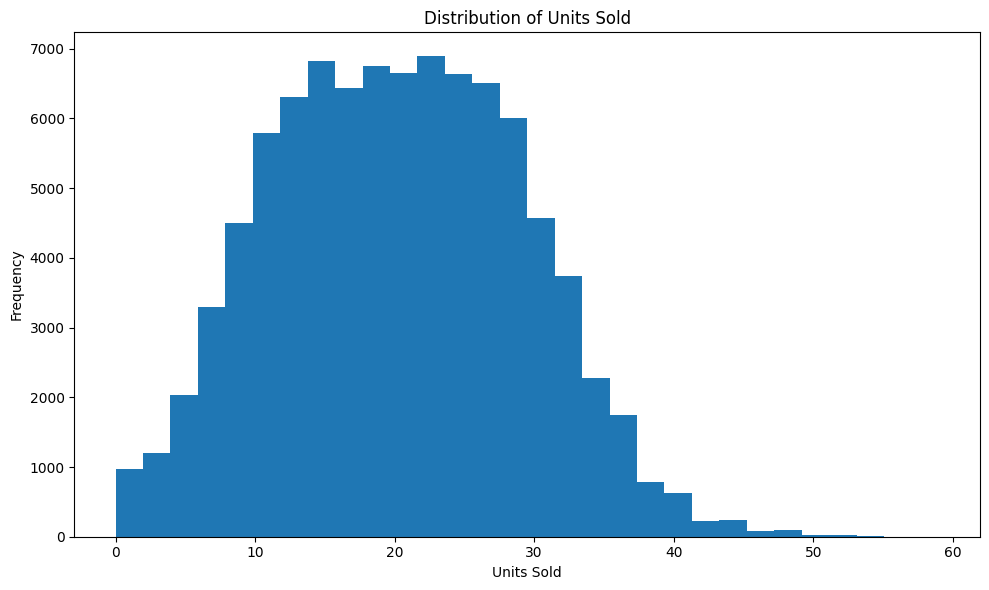

In [ ]:
# Plot the distribution of daily units sold

plt.figure(figsize=(10, 6))

plt.hist(df["Units_Sold"], bins=30)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

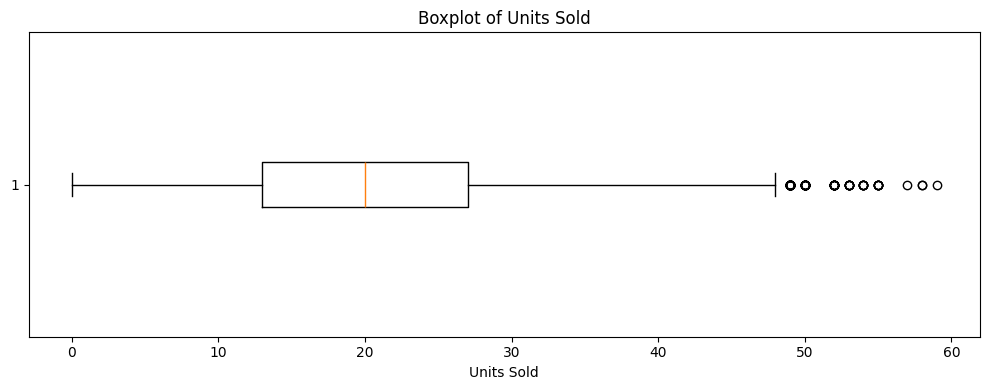

In [ ]:
# Visualize the distribution and potential extreme values

plt.figure(figsize=(10, 4))

plt.boxplot(df["Units_Sold"], vert=False)

plt.title("Boxplot of Units Sold")
plt.xlabel("Units Sold")

plt.tight_layout()
plt.show()

**Observation:**  
The distribution of `Units_Sold` is centered around 20 units, with a median
of 20 units and most observations concentrated between approximately 10 and
30 units. The histogram shows a slightly right-skewed distribution, with a
smaller number of observations extending toward higher demand levels.


The boxplot indicates that several higher-demand observations are identified
as potential statistical outliers. However, these observations are not
automatically treated as errors because unusually high demand may represent
legitimate supply-chain conditions. The distribution suggests that demand
varies across observations, making historical and temporal features useful
for next-day demand prediction.

### Demand Over Time

The daily demand pattern is examined by calculating the average `Units_Sold`
across all SKU-Warehouse combinations for each date. This analysis helps
identify temporal fluctuations and overall demand trends throughout the
observation period.

In [ ]:
# Calculate average daily demand across all SKU-Warehouse combinations

daily_demand = (
    df.groupby("Date")["Units_Sold"]
    .mean()
    .reset_index()
)

daily_demand.head()

,Date,Units_Sold
0,2024-01-01,20.216
1,2024-01-02,20.288
2,2024-01-03,21.112
3,2024-01-04,20.576
4,2024-01-05,20.832


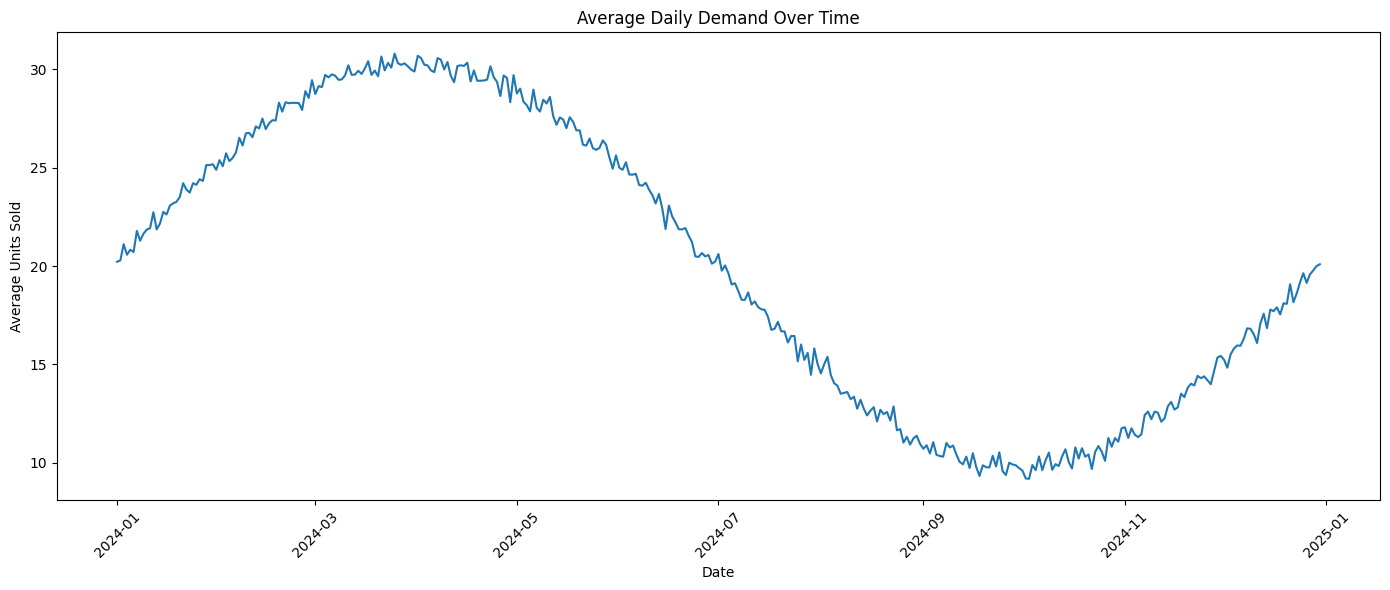

In [ ]:
# Plot average daily demand over time

plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Units_Sold"]
)

plt.title("Average Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Average Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**  
The average daily demand shows a clear temporal pattern throughout 2024.
Demand increases from approximately 20 units in January and reaches its
highest level of around 30–31 units during March and April. It then declines
gradually through the middle of the year, reaching a low of approximately
9–10 units around September and October.

Following this low-demand period, average demand increases again toward the
end of the year and reaches approximately 20 units in December. This
variation indicates that demand is not constant over time and highlights the
importance of temporal features when predicting next-day demand.

### Demand by SKU

Average demand is compared across SKUs to identify differences in product
demand levels. This analysis helps determine whether product identity is
associated with substantial variation in demand and whether SKU-specific
information may be useful for demand prediction.

In [ ]:
# Calculate average demand for each SKU

sku_demand = (
    df.groupby("SKU_ID")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

sku_demand.head(10)

,Units_Sold
SKU_ID,
SKU_18,20.402192
SKU_1,20.288219
SKU_33,20.280548
SKU_13,20.227397
SKU_47,20.225753
SKU_9,20.194521
SKU_4,20.170411
SKU_12,20.161096
SKU_3,20.156164


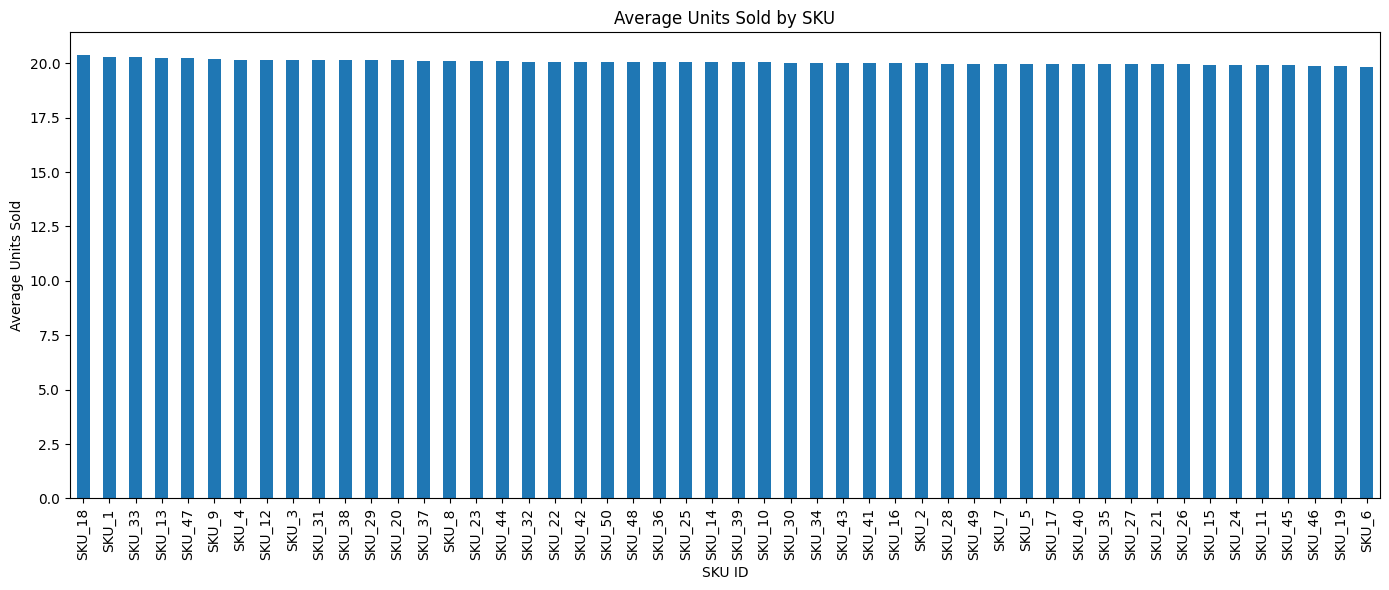

In [ ]:
# Plot average demand by SKU

plt.figure(figsize=(14, 6))

sku_demand.plot(kind="bar")

plt.title("Average Units Sold by SKU")
plt.xlabel("SKU ID")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Identify the highest- and lowest-demand SKUs

top_skus = sku_demand.head(10)
bottom_skus = sku_demand.tail(10)

print("Top 10 SKUs by average demand:")
print(top_skus.round(2))

print("\nBottom 10 SKUs by average demand:")
print(bottom_skus.round(2))

Top 10 SKUs by average demand:
SKU_ID
SKU_18    20.40
SKU_1     20.29
SKU_33    20.28
SKU_13    20.23
SKU_47    20.23
SKU_9     20.19
SKU_4     20.17
SKU_12    20.16
SKU_3     20.16
SKU_31    20.13
Name: Units_Sold, dtype: float64

Bottom 10 SKUs by average demand:
SKU_ID
SKU_27    19.96
SKU_21    19.95
SKU_26    19.94
SKU_15    19.94
SKU_24    19.93
SKU_11    19.92
SKU_45    19.92
SKU_46    19.87
SKU_19    19.87
SKU_6     19.84
Name: Units_Sold, dtype: float64


**Observation:**  
The average daily demand is relatively consistent across the 50 SKUs.
Although small differences can be observed between products, the average
demand for most SKUs remains close to 20 units.

This indicates that there is limited variation in overall average demand
between SKUs in the dataset. However, SKU-specific information may still
capture differences in day-to-day demand patterns that are not visible from
average demand alone.

### Demand by Warehouse

Average demand is compared across warehouses to determine whether different
warehouse locations exhibit meaningful differences in product demand.

Understanding warehouse-level demand variation can support inventory
allocation and replenishment planning.

In [ ]:
# Calculate average demand for each warehouse

warehouse_demand = (
    df.groupby("Warehouse_ID")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

warehouse_demand.round(2)

,Units_Sold
Warehouse_ID,
WH_1,20.10
WH_3,20.06
WH_2,20.06
WH_4,20.04
WH_5,20.01


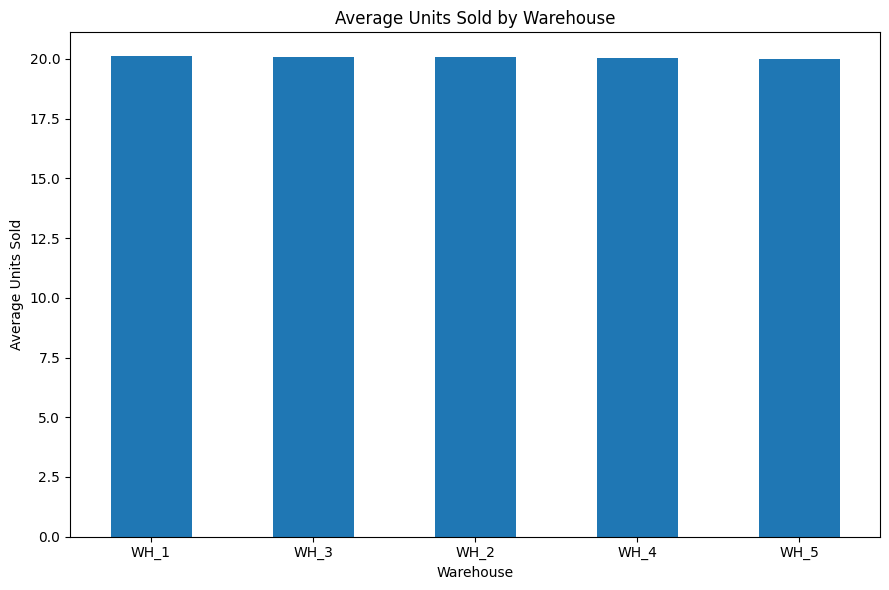

In [ ]:
# Plot average demand by warehouse

plt.figure(figsize=(9, 6))

warehouse_demand.plot(kind="bar")

plt.title("Average Units Sold by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Compare the highest and lowest average warehouse demand

highest_warehouse = warehouse_demand.idxmax()
lowest_warehouse = warehouse_demand.idxmin()

highest_value = warehouse_demand.max()
lowest_value = warehouse_demand.min()

print("Highest average demand:")
print(highest_warehouse, ":", round(highest_value, 2))

print("\nLowest average demand:")
print(lowest_warehouse, ":", round(lowest_value, 2))

print("\nDifference:",
      round(highest_value - lowest_value, 2), "units")

Highest average demand:
WH_1 : 20.1

Lowest average demand:
WH_5 : 20.01

Difference: 0.1 units


In [ ]:
# Display warehouse demand statistics

warehouse_summary = pd.DataFrame({
    "Average Units Sold": warehouse_demand.round(2),
    "Minimum Units Sold": df.groupby("Warehouse_ID")["Units_Sold"].min(),
    "Maximum Units Sold": df.groupby("Warehouse_ID")["Units_Sold"].max()
})

warehouse_summary

,Average Units Sold,Minimum Units Sold,Maximum Units Sold
Warehouse_ID,,,
WH_1,20.10,0,55
WH_2,20.06,0,54
WH_3,20.06,0,58
WH_4,20.04,0,59
WH_5,20.01,0,55


**Observation:**  
The average demand across the five warehouses is highly consistent, with
each warehouse recording an average of approximately 20 units sold per day.
Only minor differences are observed between warehouses.

This indicates that there is limited variation in overall average demand
between warehouses. However, warehouse-specific information may still be
useful for predicting day-to-day demand patterns when combined with
historical and temporal features.

### Demand by Region

Average demand is compared across regions to determine whether regional
differences exist in product demand. This analysis helps assess whether
regional information may contribute to demand prediction and supply-chain
planning.

In [ ]:
# Calculate average demand for each region

region_demand = (
    df.groupby("Region")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

region_demand.round(2)

,Units_Sold
Region,
South,20.11
East,20.06
West,20.03
North,20.02


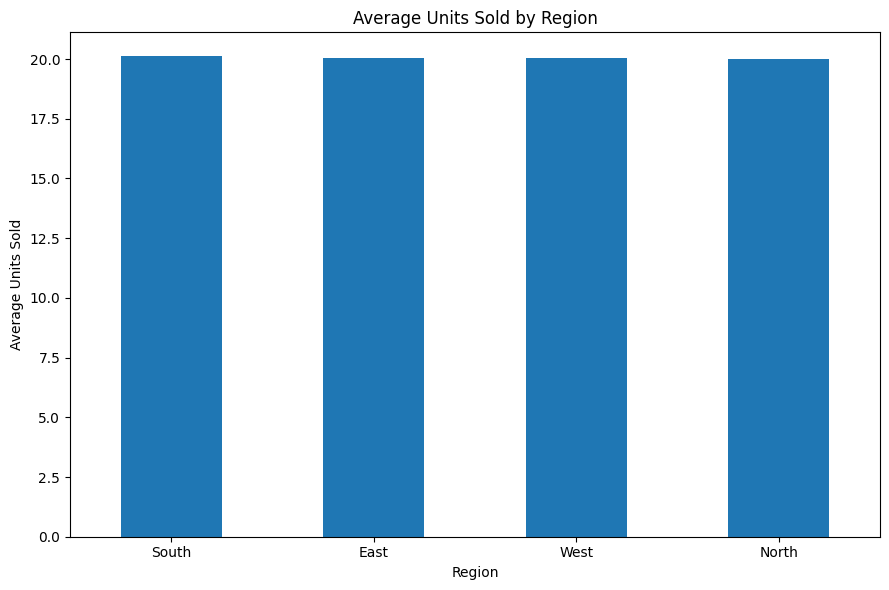

In [ ]:
# Plot average demand by region

plt.figure(figsize=(9, 6))

region_demand.plot(kind="bar")

plt.title("Average Units Sold by Region")
plt.xlabel("Region")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Compare the highest and lowest regional demand

highest_region = region_demand.idxmax()
lowest_region = region_demand.idxmin()

print("Highest average demand:")
print(highest_region, ":", round(region_demand.max(), 2))

print("\nLowest average demand:")
print(lowest_region, ":", round(region_demand.min(), 2))

print("\nDifference:",
      round(region_demand.max() - region_demand.min(), 2), "units")

Highest average demand:
South : 20.11

Lowest average demand:
North : 20.02

Difference: 0.1 units


**Observation:**  
The average daily demand is highly consistent across the four regions, with
each region recording an average of approximately 20 units sold. Only minor
differences are observed between regions.


This indicates that regional differences contribute relatively little to the
variation in overall average demand in the provided dataset. However, the
`Region` variable is retained as a categorical predictor because regional
information may still contribute to individual demand predictions when
combined with historical, temporal, and operational features.

### Promotion and Demand

The relationship between promotional activity and product demand is
examined by comparing average `Units_Sold` during promotional and
non-promotional periods. This analysis helps determine whether promotional
periods are associated with changes in observed demand.

In [ ]:
# Calculate average demand for promotional and non-promotional observations

promotion_demand = (
    df.groupby("Promotion_Flag")["Units_Sold"]
    .mean()
)

promotion_demand.round(2)

,Units_Sold
Promotion_Flag,
0,19.50
1,24.91


In [ ]:
# Create readable labels for promotion status

promotion_labels = {
    0: "No Promotion",
    1: "Promotion"
}

promotion_demand.index = promotion_demand.index.map(promotion_labels)

promotion_demand.round(2)

,Units_Sold
Promotion_Flag,
No Promotion,19.50
Promotion,24.91


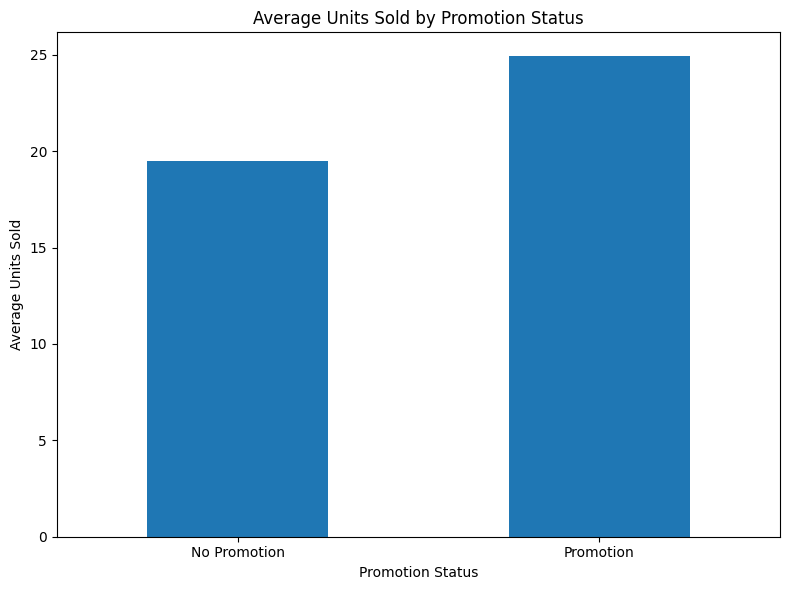

In [ ]:
# Plot average demand by promotion status

plt.figure(figsize=(8, 6))

promotion_demand.plot(kind="bar")

plt.title("Average Units Sold by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the difference in average demand

no_promotion = promotion_demand["No Promotion"]
promotion = promotion_demand["Promotion"]

difference = promotion - no_promotion
percentage_change = (difference / no_promotion) * 100

print("Average demand without promotion:", round(no_promotion, 2))
print("Average demand with promotion:", round(promotion, 2))
print("Difference:", round(difference, 2), "units")
print("Percentage difference:", round(percentage_change, 2), "%")

Average demand without promotion: 19.5
Average demand with promotion: 24.91
Difference: 5.41 units
Percentage difference: 27.74 %


**Observation:**  
A clear difference in average demand is observed between promotional and
non-promotional periods. The average number of units sold is approximately
19.5 units when no promotion is active, compared with approximately 24.9
units during promotional periods.

This represents an increase of approximately 5.4 units, or about 28%, in
observed average demand during promotional periods. The result suggests that
promotional activity is associated with higher product demand in the
dataset. However, this represents an observed association and should not be
interpreted as proof that promotions alone caused the increase.

### Price and Demand Relationship

The relationship between `Unit_Price` and `Units_Sold` is examined to
determine whether changes in product price are associated with differences
in observed demand.

In [ ]:
# Calculate the correlation between price and units sold

price_demand_corr = df["Unit_Price"].corr(df["Units_Sold"])

print(
    "Correlation between Unit Price and Units Sold:",
    round(price_demand_corr, 4)
)

Correlation between Unit Price and Units Sold: 0.0013


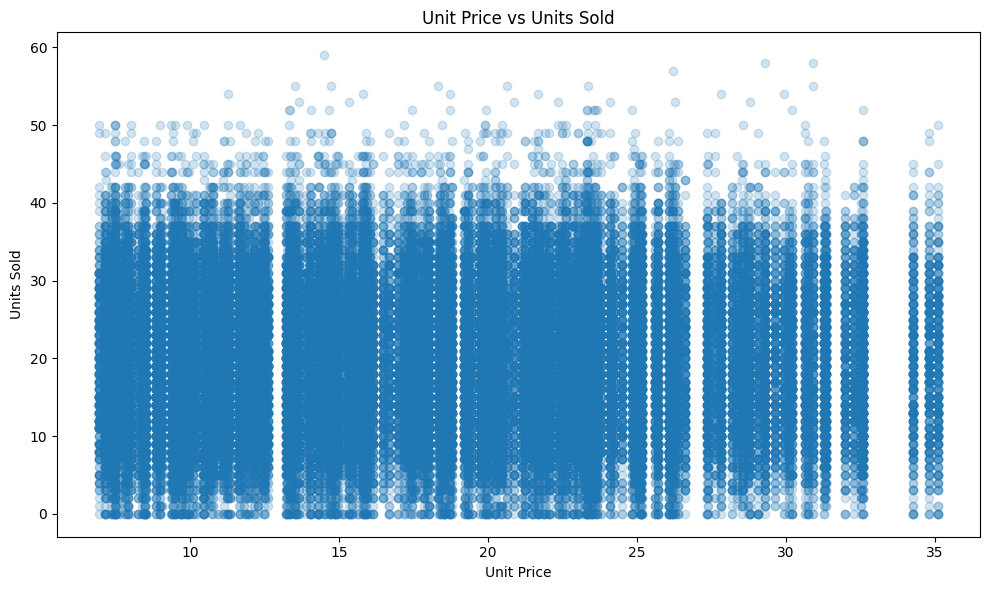

In [ ]:
# Plot the relationship between unit price and units sold

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    alpha=0.2
)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

**Observation:**  
The scatter plot shows a highly dispersed relationship between `Unit_Price`
and `Units_Sold`, with no clear increasing or decreasing linear pattern.
The correlation coefficient between the two variables is approximately 0.003,
indicating an almost negligible linear relationship in the dataset.

Therefore, unit price alone does not appear to explain much of the variation
in observed demand. However, `Unit_Price` is retained as a predictive feature
because its effect may interact with other variables such as promotions,
historical demand, and product characteristics.

### Inventory Level and Demand Relationship

The relationship between `Inventory_Level` and `Units_Sold` is examined to
determine whether inventory levels are associated with differences in
observed product demand. A correlation coefficient and scatter plot are
used to assess the strength and pattern of this relationship.

In [ ]:
# Calculate the correlation between inventory level and units sold

inventory_demand_corr = df["Inventory_Level"].corr(df["Units_Sold"])

print(
    "Correlation between Inventory Level and Units Sold:",
    round(inventory_demand_corr, 4)
)

Correlation between Inventory Level and Units Sold: -0.0643


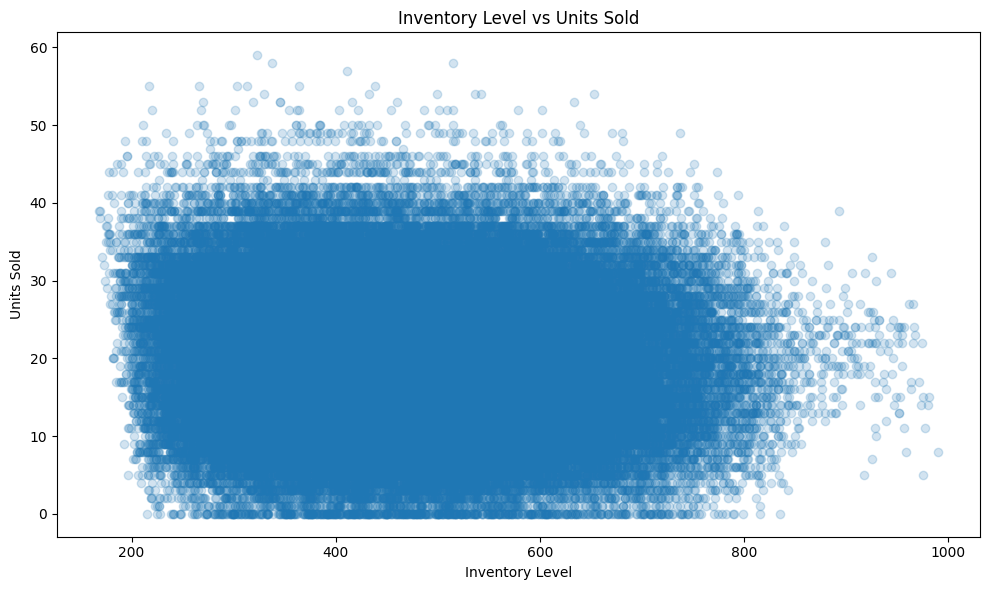

In [ ]:
# Plot the relationship between inventory level and units sold

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Inventory_Level"],
    df["Units_Sold"],
    alpha=0.2
)

plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

**Observation:**  
The scatter plot shows a highly dispersed relationship between
`Inventory_Level` and `Units_Sold`, with no clear strong linear pattern.
The correlation coefficient is approximately -0.0597, indicating a very weak
negative linear relationship between inventory level and observed demand.


This suggests that inventory level alone does not explain substantial
variation in product demand in the provided dataset. However, inventory
information is retained as a predictive feature because it may provide
additional information when combined with historical demand, promotions,
pricing, and other supply-chain variables.

### Correlation Analysis

Correlation analysis is performed to examine the linear relationships among
the numerical variables in the dataset. The analysis helps identify variables
that show stronger or weaker associations with product demand and provides
an initial basis for understanding potential predictive relationships.

In [ ]:
# Calculate the correlation matrix for numerical variables

correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix.round(3)

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
Units_Sold,1.000,-0.064,0.001,-0.002,0.069,0.002,0.001,0.180,NaN,0.949
Inventory_Level,-0.064,1.000,0.013,0.395,0.291,0.003,-0.004,-0.013,NaN,-0.060
Supplier_Lead_Time_Days,0.001,0.013,1.000,0.027,-0.000,0.072,0.072,-0.004,NaN,0.001
Reorder_Point,-0.002,0.395,0.027,1.000,0.002,0.002,-0.016,-0.002,NaN,-0.001
Order_Quantity,0.069,0.291,-0.000,0.002,1.000,0.000,0.000,0.002,NaN,0.068
Unit_Cost,0.002,0.003,0.072,0.002,0.000,1.000,0.946,0.002,NaN,0.003
Unit_Price,0.001,-0.004,0.072,-0.016,0.000,0.946,1.000,0.002,NaN,0.003
Promotion_Flag,0.180,-0.013,-0.004,-0.002,0.002,0.002,0.002,1.000,NaN,0.171
Stockout_Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Demand_Forecast,0.949,-0.060,0.001,-0.001,0.068,0.003,0.003,0.171,NaN,1.000


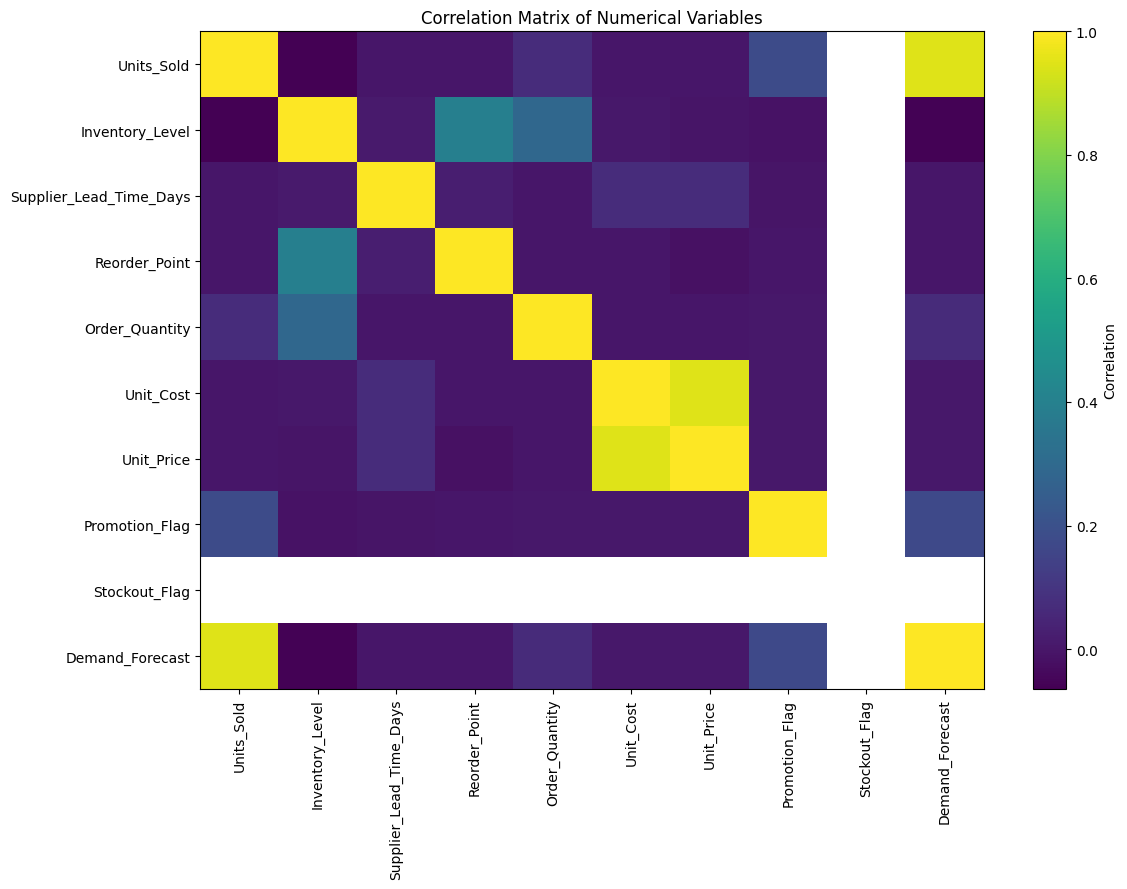

In [ ]:
# Visualize the correlation matrix

plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [ ]:
# Display correlations of numerical variables with Units Sold

units_sold_correlation = (
    correlation_matrix["Units_Sold"]
    .sort_values(ascending=False)
)

units_sold_correlation.round(3)

,Units_Sold
Units_Sold,1.000
Demand_Forecast,0.949
Promotion_Flag,0.180
Order_Quantity,0.069
Unit_Cost,0.002
Unit_Price,0.001
Supplier_Lead_Time_Days,0.001
Reorder_Point,-0.002
Inventory_Level,-0.064
Stockout_Flag,NaN


In [ ]:
# Check the relationship between Units_Sold and the existing Demand_Forecast

forecast_correlation = df["Units_Sold"].corr(df["Demand_Forecast"])

print(
    "Correlation between Units_Sold and Demand_Forecast:",
    round(forecast_correlation, 4)
)

Correlation between Units_Sold and Demand_Forecast: 0.9493


**Observation:**  
The correlation analysis shows that most operational and commercial
variables have weak linear relationships with `Units_Sold`. The relationship
between unit price and demand is particularly weak, while inventory level
also shows only a weak association with observed demand.

The existing `Demand_Forecast` variable shows a very strong correlation with
`Units_Sold`. Since this variable closely tracks actual demand, it presents a
potential target-leakage risk for future demand prediction and was therefore
excluded from the machine learning feature set.

The relatively weak pairwise correlations between individual operational
variables and demand also indicate that demand prediction may benefit from
combining multiple features, particularly historical demand and temporal
features, rather than relying on a single numerical predictor.

### Key EDA Findings

The exploratory analysis provided several important insights into the
structure and demand patterns of the supply-chain dataset.

1. **Overall demand distribution:**  
   Daily demand is centered around 20 units, with a median of 20 units and
   values ranging from 0 to 59 units. The distribution shows some higher-
   demand observations, but these are not automatically considered errors.

2. **Temporal demand pattern:**  
   Average daily demand varies considerably throughout the year. Demand
   increases during the first part of the year, reaches approximately
   30–31 units around March and April, declines to approximately 9–10 units
   around September and October, and increases again toward December.
   This demonstrates the importance of temporal information for demand
   prediction.

3. **SKU-level demand:**  
   Average demand is relatively consistent across the 50 SKUs, with most
   products having average demand close to 20 units. However, individual
   products may still have different day-to-day demand patterns.

4. **Warehouse-level demand:**  
   The five warehouses show very similar average demand levels. Therefore,
   warehouse identity does not appear to create substantial differences in
   overall average demand.

5. **Regional demand:**  
   Average demand is also highly consistent across the four regions, with
   only minor differences between them.

6. **Promotion and demand:**  
   Promotional observations have noticeably higher average demand than
   non-promotional observations. Average demand is approximately 24.9 units
   during promotional periods compared with approximately 19.5 units during
   non-promotional periods. This represents an observed difference of about
   28%.

7. **Price and demand:**  
   Unit price has an almost negligible linear relationship with units sold,
   with a correlation of approximately 0.003. The scatter plot also shows no
   clear linear pattern.

8. **Inventory and demand:**  
   Inventory level has a very weak negative linear relationship with units
   sold, with a correlation of approximately -0.060.

9. **Existing demand forecast:**  
   The provided `Demand_Forecast` variable has a very strong relationship
   with `Units_Sold`, with a correlation of approximately 0.949. Because it
   closely tracks actual demand, it was excluded from predictive modeling
   to reduce the risk of target leakage.

Overall, the EDA indicates that historical demand and temporal patterns are
likely to be particularly important for next-day demand prediction, while
promotion and other operational variables may provide additional predictive
information when considered together.

# Statistical Analysis

Statistical analysis is performed to formally examine relationships identified
during the exploratory data analysis. Appropriate statistical tests are used
to determine whether observed differences and associations in product demand
are statistically significant.

The analysis focuses on the relationship between promotional activity and
demand, correlations between numerical variables and demand, and differences
in demand across regions. A significance level of 0.05 is used for hypothesis
testing.

### Statistical Test for Promotion and Demand

An independent samples t-test is used to examine whether the mean `Units_Sold`
differs significantly between promotional and non-promotional observations.

The null hypothesis states that there is no difference in mean demand between
the two groups, while the alternative hypothesis states that the mean demand
differs between promotional and non-promotional observations.

**Hypotheses:**

- **H₀ (Null Hypothesis):** The mean demand during promotional periods is
  equal to the mean demand during non-promotional periods.

- **H₁ (Alternative Hypothesis):** The mean demand during promotional
  periods is different from the mean demand during non-promotional periods.

A significance level of α = 0.05 is used.

In [ ]:
from scipy.stats import ttest_ind

In [ ]:
# Separate demand into promotion and non-promotion groups

promotion_group = df[df["Promotion_Flag"] == 1]["Units_Sold"]
no_promotion_group = df[df["Promotion_Flag"] == 0]["Units_Sold"]

print("Promotion observations:", len(promotion_group))
print("No-promotion observations:", len(no_promotion_group))

print("\nMean demand during promotion:",
      round(promotion_group.mean(), 2))

print("Mean demand without promotion:",
      round(no_promotion_group.mean(), 2))

Promotion observations: 9270
No-promotion observations: 81980

Mean demand during promotion: 24.91
Mean demand without promotion: 19.5


In [ ]:
# Perform an independent samples t-test

t_statistic, p_value = ttest_ind(
    promotion_group,
    no_promotion_group,
    equal_var=False
)

print("T-statistic:", round(t_statistic, 4))
print("P-value:", p_value)

T-statistic: 44.6215
P-value: 0.0


In [ ]:
# Interpret the statistical test

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in mean demand "
          "between promotional and non-promotional observations.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a statistically significant "
          "difference in mean demand.")

Result: Reject the null hypothesis.
There is a statistically significant difference in mean demand between promotional and non-promotional observations.


**Observation:**  
The independent samples t-test produced a t-statistic of 44.6215 and a
p-value of less than 0.001. Since the p-value is below the significance
level of 0.05, the null hypothesis is rejected.

This provides strong statistical evidence that the mean observed demand
differs between promotional and non-promotional periods. The earlier
descriptive analysis showed that average demand was approximately 24.9 units
during promotional periods compared with approximately 19.5 units during
non-promotional periods.

However, statistical significance indicates an association between promotion
and demand and does not by itself establish that promotional activity caused
the increase in demand.

### Correlation Significance

Pearson Correlation Analysis is used to examine the strength and direction of
linear relationships between selected numerical variables and `Units_Sold`.

The Pearson correlation coefficient ranges from -1 to +1, where values close
to +1 indicate a strong positive linear relationship, values close to -1
indicate a strong negative linear relationship, and values close to 0
indicate a weak linear relationship.

The corresponding p-values are used to determine whether the observed
correlations are statistically significant at a significance level of 0.05.

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Variables to test against Units_Sold

correlation_variables = [
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Promotion_Flag"
]

correlation_results = []

for variable in correlation_variables:
    r_value, p_value = pearsonr(
        df[variable],
        df["Units_Sold"]
    )

    correlation_results.append({
        "Variable": variable,
        "Correlation (r)": r_value,
        "P-value": p_value
    })

correlation_results = pd.DataFrame(correlation_results)

correlation_results["Correlation (r)"] = (
    correlation_results["Correlation (r)"].round(4)
)

correlation_results["P-value"] = (
    correlation_results["P-value"].apply(
        lambda x: f"{x:.4e}"
    )
)

correlation_results# Variables to test against Units_Sold

correlation_variables = [
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Promotion_Flag"
]

correlation_results = []

for variable in correlation_variables:
    r_value, p_value = pearsonr(
        df[variable],
        df["Units_Sold"]
    )

    correlation_results.append({
        "Variable": variable,
        "Correlation (r)": r_value,
        "P-value": p_value
    })

correlation_results = pd.DataFrame(correlation_results)

correlation_results["Correlation (r)"] = (
    correlation_results["Correlation (r)"].round(4)
)

correlation_results["P-value"] = (
    correlation_results["P-value"].apply(
        lambda x: f"{x:.4e}"
    )
)

correlation_results

,Variable,Correlation (r),P-value
0,Inventory_Level,-0.0643,3.6236e-84
1,Supplier_Lead_Time_Days,0.0005,8.7798e-01
2,Reorder_Point,-0.0016,6.2236e-01
3,Order_Quantity,0.0693,1.3081e-97
4,Unit_Cost,0.0017,6.1425e-01
5,Unit_Price,0.0013,6.9583e-01
6,Promotion_Flag,0.1802,0.0000e+00


In [ ]:
# Create a separate statistical results table

statistical_results = []

for variable in correlation_variables:
    r_value, p_value = pearsonr(
        df[variable],
        df["Units_Sold"]
    )

    statistical_results.append({
        "Variable": variable,
        "Correlation (r)": round(r_value, 4),
        "P-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

statistical_results = pd.DataFrame(statistical_results)

statistical_results

,Variable,Correlation (r),P-value,Significant
0,Inventory_Level,-0.0643,3.623565e-84,Yes
1,Supplier_Lead_Time_Days,0.0005,8.779761e-01,No
2,Reorder_Point,-0.0016,6.223628e-01,No
3,Order_Quantity,0.0693,1.308144e-97,Yes
4,Unit_Cost,0.0017,6.142533e-01,No
5,Unit_Price,0.0013,6.958279e-01,No
6,Promotion_Flag,0.1802,0.000000e+00,Yes


In [ ]:
# Identify the strongest absolute correlation

strongest_index = (
    statistical_results["Correlation (r)"]
    .abs()
    .idxmax()
)

print(
    "Strongest linear relationship:",
    statistical_results.loc[strongest_index, "Variable"]
)

print(
    "Correlation:",
    statistical_results.loc[strongest_index, "Correlation (r)"]
)

Strongest linear relationship: Promotion_Flag
Correlation: 0.1802


**Observation:**  
Pearson correlation analysis shows that `Promotion_Flag` has the strongest
linear relationship with `Units_Sold` among the variables tested, with a
correlation coefficient of 0.1802 and a p-value below 0.001. This represents
a statistically significant but relatively weak positive relationship.

`Order_Quantity` also shows a statistically significant positive relationship
with `Units_Sold` (r = 0.0693, p < 0.001), while `Inventory_Level` shows a
statistically significant but very weak negative relationship (r = -0.0643,
p < 0.001).

The relationships between `Supplier_Lead_Time_Days`, `Reorder_Point`,
`Unit_Cost`, and `Unit_Price` and `Units_Sold` are not statistically
significant at the 0.05 level.

Although some correlations are statistically significant, their small
magnitudes indicate that these individual variables have weak linear
relationships with demand. Therefore, demand prediction should consider
multiple variables together, particularly historical demand and temporal
features, rather than relying on individual correlations.

### Regional Demand Analysis

A one-way ANOVA test is used to determine whether the mean `Units_Sold`
differs significantly across the four regions.

The null hypothesis states that all regions have the same mean demand, while
the alternative hypothesis states that at least one region has a different
mean demand.

A significance level of α = 0.05 is used.

**Hypotheses:**

- **H₀ (Null Hypothesis):** The mean demand is equal across all four regions.

- **H₁ (Alternative Hypothesis):** At least one region has a different mean
  demand.

If the p-value is below 0.05, the null hypothesis will be rejected.

In [ ]:
from scipy.stats import f_oneway

In [ ]:
# Separate Units_Sold into groups based on Region

region_groups = [
    group["Units_Sold"].values
    for _, group in df.groupby("Region")
]

print("Number of regions:", len(region_groups))

Number of regions: 4


In [ ]:
# Perform one-way ANOVA

f_statistic, p_value = f_oneway(*region_groups)

print("F-statistic:", round(f_statistic, 4))
print("P-value:", p_value)

F-statistic: 0.4842
P-value: 0.6932828337128684


In [ ]:
# Interpret the ANOVA result

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in mean demand "
          "among the regions.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is insufficient evidence of a statistically significant "
          "difference in mean demand among the regions.")

Result: Fail to reject the null hypothesis.
There is insufficient evidence of a statistically significant difference in mean demand among the regions.


In [ ]:
# Display mean demand for each region

region_means = (
    df.groupby("Region")["Units_Sold"]
    .mean()
    .sort_values(ascending=False)
)

print("Mean demand by region:")
print(region_means.round(2))

Mean demand by region:
Region
South    20.11
East     20.06
West     20.03
North    20.02
Name: Units_Sold, dtype: float64


**Observation:**  
The one-way ANOVA test produced an F-statistic of 0.4842 and a p-value of
0.6933. Since the p-value is greater than the significance level of 0.05,
the null hypothesis is not rejected.

Therefore, there is insufficient statistical evidence to conclude that mean
demand differs significantly across the four regions. This is consistent
with the EDA finding that average demand was very similar across regions.

The result suggests that regional differences have limited influence on
overall average demand in the provided dataset. However, `Region` is
retained as a categorical predictor because it may still provide useful
information when combined with other variables in the machine learning
models.

### Statistical Analysis Findings

The statistical analysis provided formal evidence for several patterns
identified during the exploratory analysis.

1. **Promotion and demand:**  
   The independent samples t-test produced a t-statistic of 44.6215 and a
   p-value below 0.001. The null hypothesis was rejected, indicating a
   statistically significant difference in mean demand between promotional
   and non-promotional observations. Promotional periods recorded higher
   observed average demand.

2. **Numerical variables and demand:**  
   Pearson correlation analysis showed that `Promotion_Flag` had the
   strongest linear relationship with `Units_Sold` among the tested
   numerical variables (r = 0.1802, p < 0.001). `Order_Quantity` also showed
   a statistically significant but weak positive relationship (r = 0.0693,
   p < 0.001), while `Inventory_Level` showed a very weak negative
   relationship (r = -0.0643, p < 0.001). The remaining tested variables
   did not show statistically significant linear relationships with demand.

3. **Regional demand:**  
   The one-way ANOVA produced an F-statistic of 0.4842 and a p-value of
   0.6933. Since the p-value is greater than 0.05, the null hypothesis was
   not rejected. Therefore, there is insufficient evidence to conclude that
   mean demand differs significantly across the four regions.

Overall, the statistical analysis supports the EDA findings that promotional
activity is associated with higher observed demand, while regional and
several individual numerical variables show weak relationships with demand.
The results also support the use of multiple historical, temporal,
operational, and commercial features for next-day demand prediction rather
than relying on a single variable.

# Machine Learning Methodology

Machine learning models are developed to predict next-day product demand
using historical demand, temporal, operational, commercial, and categorical
information.

The prediction task is formulated as a supervised regression problem, where
`Next_Day_Units_Sold` is the target variable. A chronological train-test
split is used so that earlier observations are used for model development
and later observations are reserved for evaluation.

Three regression approaches are considered: Linear Regression as a baseline
machine learning model, Decision Tree Regression to capture nonlinear
relationships, and Random Forest Regression to improve predictive performance
through an ensemble of decision trees.

The models are evaluated using regression metrics including Mean Absolute
Error (MAE), Root Mean Squared Error (RMSE), and R² score.

### Model Selection

Three regression models are selected to provide different approaches to the
next-day demand prediction problem.

**Linear Regression** is used as a simple baseline model to establish the
performance of a linear relationship between the predictors and future
demand.

**Decision Tree Regression** is used to capture nonlinear relationships and
interactions between demand-related features.

**Random Forest Regression** is used as an ensemble approach that combines
multiple decision trees and can capture complex nonlinear relationships
while reducing the dependence on a single tree.

Using these three models allows their predictive performance to be compared
using the same training and testing data.

### Baseline Model

A simple persistence baseline is established before training the machine
learning models. The baseline predicts the next day's demand using the most
recent observed demand (`lag_1`).

This provides a straightforward benchmark against which the machine learning
models can be compared. A useful machine learning model should provide
better predictive performance than this simple historical-demand baseline.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Use the previous day's demand as the baseline prediction

baseline_predictions = X_test["lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Performance")
print("--------------------")
print("MAE :", round(baseline_mae, 4))
print("RMSE:", round(baseline_rmse, 4))
print("R²  :", round(baseline_r2, 4))

Baseline Performance
--------------------
MAE : 5.8938
RMSE: 7.4303
R²  : -0.5179


**Observation:**  
The persistence baseline, which uses the previous day's demand (`lag_1`) to
predict next-day demand, achieved an MAE of 5.8938, an RMSE of 7.4303, and an
R² score of -0.5179.

The negative R² indicates that this simple baseline does not explain the
variation in the test-period demand effectively. This provides a useful
benchmark for evaluating whether the machine learning models can improve
next-day demand prediction by combining historical, temporal, operational,
commercial, and categorical features.

### Linear Regression

Linear Regression is used as the first machine learning model for predicting
next-day demand. It provides a simple and interpretable baseline for
understanding how the selected features collectively relate to the target
variable.

The model is trained using the preprocessed training data and evaluated on
the unseen testing data. Its performance will later be compared with the
Decision Tree and Random Forest regression models.

In [ ]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Generate predictions on training and testing data

linear_train_predictions = linear_model.predict(X_train_processed)
linear_test_predictions = linear_model.predict(X_test_processed)

print("Training predictions generated:", len(linear_train_predictions))
print("Testing predictions generated:", len(linear_test_predictions))

Training predictions generated: 70000
Testing predictions generated: 17500


In [ ]:
# Evaluate Linear Regression performance

linear_train_mae = mean_absolute_error(
    y_train,
    linear_train_predictions
)

linear_test_mae = mean_absolute_error(
    y_test,
    linear_test_predictions
)

linear_train_rmse = np.sqrt(
    mean_squared_error(y_train, linear_train_predictions)
)

linear_test_rmse = np.sqrt(
    mean_squared_error(y_test, linear_test_predictions)
)

linear_train_r2 = r2_score(
    y_train,
    linear_train_predictions
)

linear_test_r2 = r2_score(
    y_test,
    linear_test_predictions
)

print("Linear Regression Performance")
print("-----------------------------")
print("Training MAE :", round(linear_train_mae, 4))
print("Testing MAE  :", round(linear_test_mae, 4))
print("Training RMSE:", round(linear_train_rmse, 4))
print("Testing RMSE :", round(linear_test_rmse, 4))
print("Training R²  :", round(linear_train_r2, 4))
print("Testing R²   :", round(linear_test_r2, 4))

Linear Regression Performance
-----------------------------
Training MAE : 4.4323
Testing MAE  : 5.429
Training RMSE: 5.632
Testing RMSE : 6.8054
Training R²  : 0.6377
Testing R²   : -0.2733


**Observation:**  
The Linear Regression model achieved a training MAE of 4.4323 and a testing
MAE of 5.4290. The corresponding RMSE values were 5.6320 for training and
6.8054 for testing.

The training R² score was 0.6377, while the testing R² score was -0.2733.
The difference between training and testing performance indicates that the
model does not generalize well to the unseen test period. The negative
testing R² suggests that the model performs poorly in explaining the
variation in next-day demand on the test data.

Although Linear Regression performs better than the persistence baseline in
terms of MAE and RMSE, its negative testing R² indicates that a simple linear
relationship is not sufficient for accurately capturing the demand patterns
in this dataset.

### Decision Tree Regressor

A Decision Tree Regressor is used to model nonlinear relationships between
the input features and next-day demand. Unlike Linear Regression, a decision
tree can learn threshold-based relationships and interactions between
features.

The model is trained using the same preprocessed training data and evaluated
on the same unseen testing data to ensure a fair comparison with Linear
Regression.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree model
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# Generate predictions for training and testing data

tree_train_predictions = decision_tree_model.predict(
    X_train_processed
)

tree_test_predictions = decision_tree_model.predict(
    X_test_processed
)

print("Training predictions generated:", len(tree_train_predictions))
print("Testing predictions generated:", len(tree_test_predictions))

Training predictions generated: 70000
Testing predictions generated: 17500


In [ ]:
# Evaluate Decision Tree performance

tree_train_mae = mean_absolute_error(
    y_train,
    tree_train_predictions
)

tree_test_mae = mean_absolute_error(
    y_test,
    tree_test_predictions
)

tree_train_rmse = np.sqrt(
    mean_squared_error(y_train, tree_train_predictions)
)

tree_test_rmse = np.sqrt(
    mean_squared_error(y_test, tree_test_predictions)
)

tree_train_r2 = r2_score(
    y_train,
    tree_train_predictions
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_predictions
)

print("Decision Tree Performance")
print("-------------------------")
print("Training MAE :", round(tree_train_mae, 4))
print("Testing MAE  :", round(tree_test_mae, 4))
print("Training RMSE:", round(tree_train_rmse, 4))
print("Testing RMSE :", round(tree_test_rmse, 4))
print("Training R²  :", round(tree_train_r2, 4))
print("Testing R²   :", round(tree_test_r2, 4))

Decision Tree Performance
-------------------------
Training MAE : 0.0
Testing MAE  : 8.2031
Training RMSE: 0.0
Testing RMSE : 10.1523
Training R²  : 1.0
Testing R²   : -1.8337


**Observation:**  
The Decision Tree Regressor achieved perfect performance on the training data,
with an MAE and RMSE of 0.0000 and an R² score of 1.0000. However, its
performance on the testing data was substantially poorer, with an MAE of
8.2031, an RMSE of 10.1523, and an R² score of -1.8337.

The large difference between training and testing performance indicates
severe overfitting. The unrestricted decision tree has learned the training
observations too closely and fails to generalize effectively to the unseen
test period.

The Decision Tree therefore performs worse than both the persistence
baseline and Linear Regression on the testing data. This result demonstrates
the importance of controlling model complexity when applying tree-based
models to demand prediction.

### Random Forest Regressor

A Random Forest Regressor is used as an ensemble learning approach for
next-day demand prediction. The model combines multiple decision trees and
aggregates their predictions to improve generalization and reduce the
dependence on a single decision tree.

The Random Forest model is trained using the same preprocessed training data
and evaluated on the same chronological testing period used for the previous
models. Its performance is compared with the persistence baseline, Linear
Regression, and Decision Tree models.

In [110]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [111]:
# Generate predictions for training and testing data

rf_train_predictions = random_forest_model.predict(
    X_train_processed
)

rf_test_predictions = random_forest_model.predict(
    X_test_processed
)

print("Training predictions generated:", len(rf_train_predictions))
print("Testing predictions generated:", len(rf_test_predictions))

Training predictions generated: 70000
Testing predictions generated: 17500


In [112]:
# Evaluate Random Forest performance

rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_predictions
)

rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_predictions)
)

rf_test_rmse = np.sqrt(
    mean_squared_error(y_test, rf_test_predictions)
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_predictions
)

print("Random Forest Performance")
print("-------------------------")
print("Training MAE :", round(rf_train_mae, 4))
print("Testing MAE  :", round(rf_test_mae, 4))
print("Training RMSE:", round(rf_train_rmse, 4))
print("Testing RMSE :", round(rf_test_rmse, 4))
print("Training R²  :", round(rf_train_r2, 4))
print("Testing R²   :", round(rf_test_r2, 4))

Random Forest Performance
-------------------------
Training MAE : 1.6384
Testing MAE  : 5.9319
Training RMSE: 2.0981
Testing RMSE : 7.4302
Training R²  : 0.9497
Testing R²   : -0.5178


**Observation:**  
The Random Forest Regressor achieved strong performance on the training data,
with an MAE of 1.6384, an RMSE of 2.0981, and an R² score of 0.9497.
However, its performance on the testing data was considerably poorer, with
an MAE of 5.9319, an RMSE of 7.4302, and an R² score of -0.5178.

The large difference between training and testing performance indicates that
the Random Forest model has overfitted the training data and does not
generalize well to the unseen test period.

On the testing data, the Random Forest performs slightly worse than the
Linear Regression model and is approximately similar to the persistence
baseline. Therefore, increasing model complexity does not necessarily
improve demand prediction for this dataset.

### Model Training Summary

Three regression models were trained and evaluated for next-day demand
prediction: Linear Regression, Decision Tree Regressor, and Random Forest
Regressor. A persistence baseline using the previous day's demand was also
established for comparison.

All models were trained using the same chronological training and testing
periods. Performance was assessed using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE), and R² score.

The testing results are summarized below.

| Model | Test MAE | Test RMSE | Test R² |
|---|---:|---:|---:|
| Persistence Baseline | 5.8938 | 7.4303 | -0.5179 |
| Linear Regression | **5.4290** | **6.8054** | **-0.2733** |
| Decision Tree | 8.2031 | 10.1523 | -1.8337 |
| Random Forest | 5.9319 | 7.4302 | -0.5178 |

Among the evaluated approaches, Linear Regression achieved the lowest test
MAE and RMSE and the highest test R² score. The Decision Tree showed severe
overfitting, while the Random Forest also showed a substantial gap between
training and testing performance.

These results indicate that the simpler Linear Regression model currently
provides the best generalization among the tested models. Detailed model
evaluation and visual comparison are presented in the following section.

In [113]:
# Create a comparison table of model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Test MAE": [
        baseline_mae,
        linear_test_mae,
        tree_test_mae,
        rf_test_mae
    ],
    "Test RMSE": [
        baseline_rmse,
        linear_test_rmse,
        tree_test_rmse,
        rf_test_rmse
    ],
    "Test R²": [
        baseline_r2,
        linear_test_r2,
        tree_test_r2,
        rf_test_r2
    ]
})

model_comparison.round(4)

,Model,Test MAE,Test RMSE,Test R²
0,Persistence Baseline,5.8938,7.4303,-0.5179
1,Linear Regression,5.4290,6.8054,-0.2733
2,Decision Tree,8.2031,10.1523,-1.8337
3,Random Forest,5.9319,7.4302,-0.5178


**Observation:**  
The model comparison shows that Linear Regression produced the best testing
performance among the evaluated approaches, with a test MAE of 5.4290, RMSE
of 6.8054, and R² of -0.2733.

The Decision Tree produced the weakest testing performance and showed clear
signs of overfitting. Although the Random Forest substantially improved upon
the training performance of the Decision Tree, its testing performance did
not improve over the simpler models.

Therefore, Linear Regression is selected as the current best-performing model
based on the unseen testing data. Further evaluation, visualization, and
model interpretation will be performed in the next section.

# Model Evaluation & Results

The trained models are evaluated using their performance on the unseen
testing dataset. The evaluation focuses on prediction accuracy, error
magnitude, and the ability of each model to generalize beyond the training
data.

Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score are
used as the primary evaluation metrics. The models are compared using the
same testing period to ensure a fair evaluation.

Prediction visualizations and error analysis are also performed to better
understand the strengths and limitations of the trained models.

### Evaluation Metrics

Three regression metrics are used to evaluate model performance.

**Mean Absolute Error (MAE)** measures the average absolute difference
between the actual and predicted demand. Lower MAE indicates smaller
prediction errors.

**Root Mean Squared Error (RMSE)** measures the square root of the average
squared prediction errors. RMSE gives greater weight to larger errors, so
lower values indicate better performance.

**R² Score** measures how well the model explains the variation in the target
variable. Higher values generally indicate better explanatory performance,
with 1 representing a perfect fit. A negative R² indicates that the model
performs worse than a simple mean-based prediction on the evaluated data.

### Model Performance Comparison

The testing performance of the persistence baseline, Linear Regression,
Decision Tree, and Random Forest models is compared using MAE, RMSE, and R²
scores.

The comparison helps identify which model provides the best performance on
unseen data and whether the more complex machine learning models improve
upon the simpler baseline and Linear Regression approach.

In [114]:
# Display the testing performance of all evaluated models

model_comparison = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Test MAE": [
        baseline_mae,
        linear_test_mae,
        tree_test_mae,
        rf_test_mae
    ],
    "Test RMSE": [
        baseline_rmse,
        linear_test_rmse,
        tree_test_rmse,
        rf_test_rmse
    ],
    "Test R²": [
        baseline_r2,
        linear_test_r2,
        tree_test_r2,
        rf_test_r2
    ]
})

model_comparison.round(4)

,Model,Test MAE,Test RMSE,Test R²
0,Persistence Baseline,5.8938,7.4303,-0.5179
1,Linear Regression,5.4290,6.8054,-0.2733
2,Decision Tree,8.2031,10.1523,-1.8337
3,Random Forest,5.9319,7.4302,-0.5178


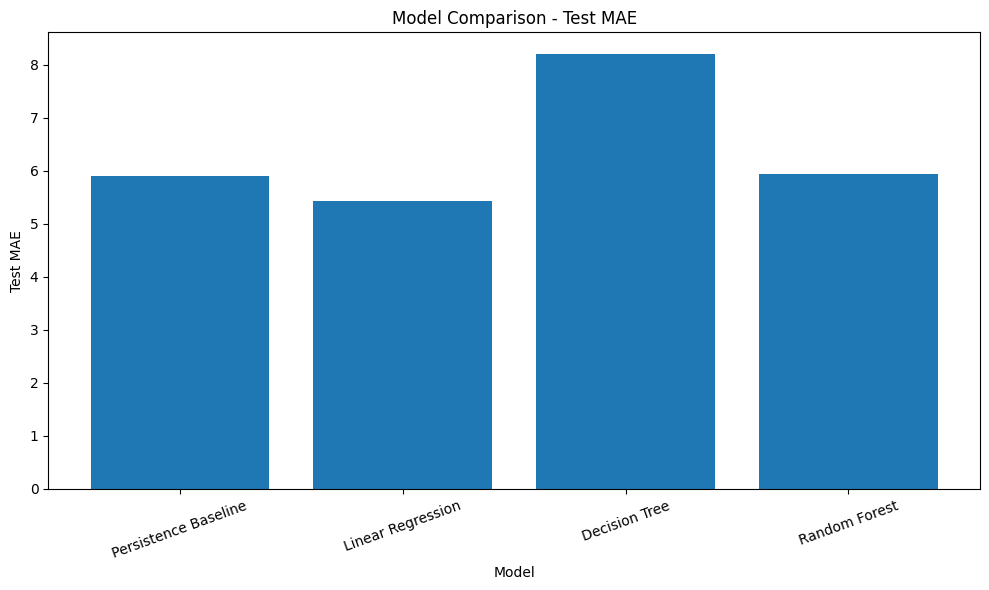

In [115]:
# Compare testing MAE across models

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test MAE"]
)

plt.title("Model Comparison - Test MAE")
plt.xlabel("Model")
plt.ylabel("Test MAE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Observation:**  
The model comparison shows that Linear Regression achieved the lowest testing
MAE of 5.4290 among the evaluated models. The persistence baseline and Random
Forest achieved testing MAE values of 5.8938 and 5.9319 respectively, while
the Decision Tree produced the highest testing MAE of 8.2031.

Since lower MAE indicates smaller average prediction errors, Linear
Regression currently provides the best performance among the evaluated
approaches. The result also shows that the more complex tree-based models
did not provide better generalization than the simpler Linear Regression
model.

### Actual vs Predicted Demand

The actual and predicted next-day demand values are compared to visually
assess the predictive performance of the best-performing model identified so
far, Linear Regression.

A scatter plot is used to determine how closely the predicted values follow
the actual demand values. Predictions closer to the diagonal reference line
represent smaller prediction errors.

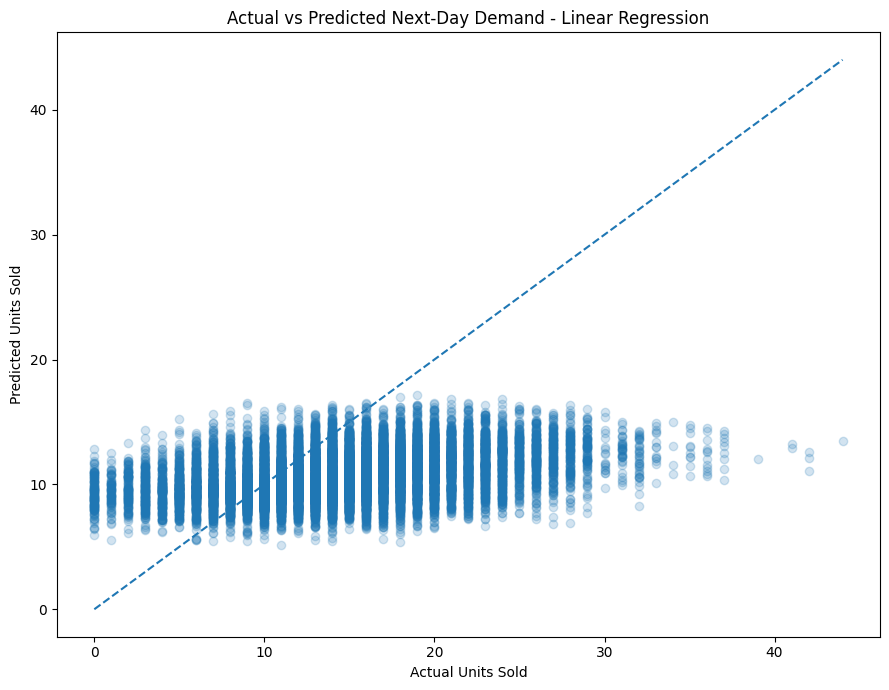

In [116]:
# Plot actual vs predicted demand for Linear Regression

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    linear_test_predictions,
    alpha=0.2
)

# Reference line: perfect predictions
min_value = min(y_test.min(), linear_test_predictions.min())
max_value = max(y_test.max(), linear_test_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Next-Day Demand - Linear Regression")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.tight_layout()
plt.show()

**Observation:**  
The actual-versus-predicted plot shows that the Linear Regression model's
predictions are concentrated within a relatively narrow range, while the
actual demand values show substantially greater variation.

The predictions do not closely follow the diagonal reference line representing
perfect predictions. In particular, the model tends to underestimate higher
actual demand values and does not fully capture the variation in next-day
demand.

This visual pattern is consistent with the negative testing R² score of
-0.2733 and indicates that the Linear Regression model has limited ability to
generalize to the unseen test period.

### Prediction Error Analysis

Prediction errors are analyzed to understand how the Linear Regression model
performs across different demand levels.

The residual is calculated as the difference between the actual and predicted
next-day demand. A residual close to zero indicates an accurate prediction,
while larger positive or negative residuals indicate larger prediction errors.

The distribution of residuals and their relationship with actual demand are
examined to identify potential patterns or systematic prediction errors.

In [117]:
# Calculate prediction errors (residuals)

linear_residuals = y_test - linear_test_predictions

print("Mean residual:", round(linear_residuals.mean(), 4))
print("Minimum residual:", round(linear_residuals.min(), 4))
print("Maximum residual:", round(linear_residuals.max(), 4))

Mean residual: 3.9098
Minimum residual: -12.8236
Maximum residual: 30.9044


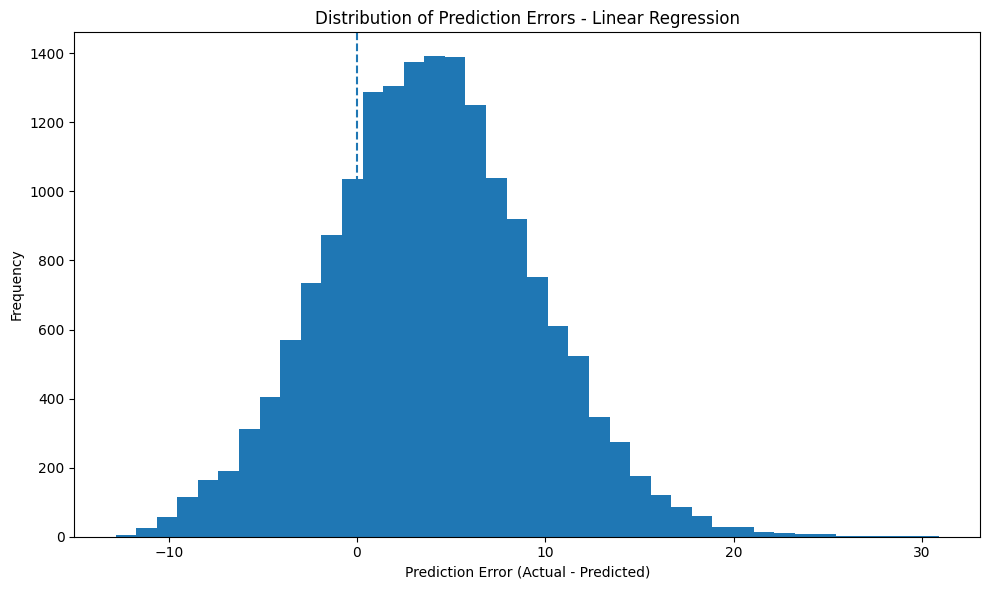

In [118]:
# Plot the distribution of prediction errors

plt.figure(figsize=(10, 6))

plt.hist(
    linear_residuals,
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors - Linear Regression")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

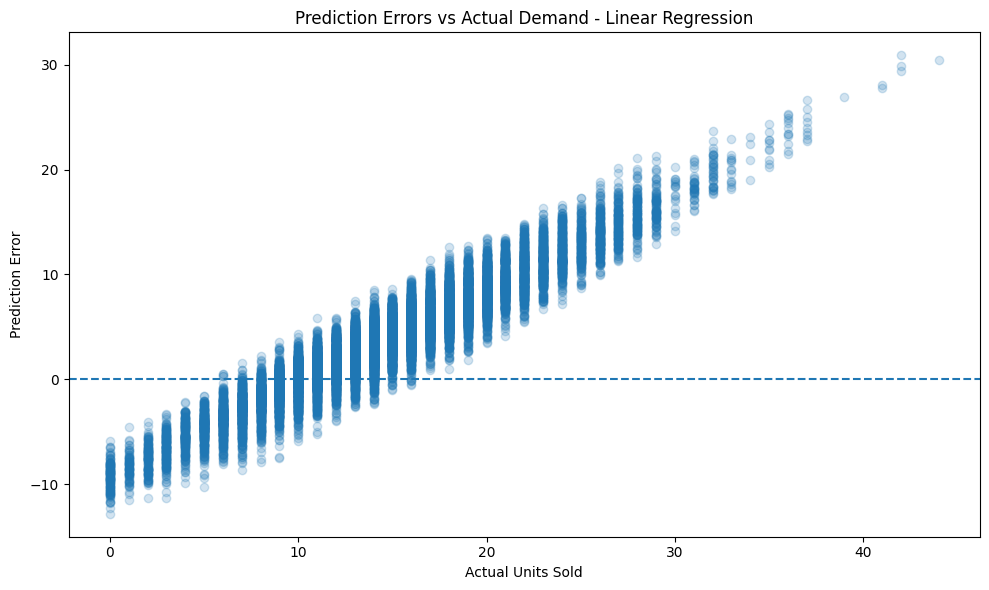

In [119]:
# Plot prediction errors against actual demand

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    linear_residuals,
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Prediction Errors vs Actual Demand - Linear Regression")
plt.xlabel("Actual Units Sold")
plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

**Observation:**  
The residual analysis shows that the mean prediction error is 3.9098 units,
with residuals ranging from -12.8236 to 30.9044 units. The positive mean
residual indicates an overall tendency of the model to underestimate actual
demand.

The residual distribution is concentrated mainly on the positive side of
zero, confirming this underprediction tendency. The residual-versus-actual
demand plot shows a clear increasing pattern: as actual demand increases,
the prediction error also increases.

This indicates that the Linear Regression model does not capture higher
demand levels effectively. The systematic pattern in the residuals suggests
that the model has limited ability to represent the nonlinear or more
complex relationships present in the demand data.

### Model Generalization & Overfitting

The difference between training and testing performance is examined to
evaluate how well the models generalize to unseen demand observations.

A model that performs substantially better on training data than on testing
data may be overfitting the training observations. Therefore, the training
and testing MAE, RMSE, and R² scores are compared for the Linear Regression,
Decision Tree, and Random Forest models.

This comparison helps determine whether model complexity improves
generalization or instead causes the model to fit the training data too
closely.

In [120]:
# Compare training and testing performance

generalization_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Training MAE": [
        linear_train_mae,
        tree_train_mae,
        rf_train_mae
    ],
    "Testing MAE": [
        linear_test_mae,
        tree_test_mae,
        rf_test_mae
    ],
    "Training RMSE": [
        linear_train_rmse,
        tree_train_rmse,
        rf_train_rmse
    ],
    "Testing RMSE": [
        linear_test_rmse,
        tree_test_rmse,
        rf_test_rmse
    ],
    "Training R²": [
        linear_train_r2,
        tree_train_r2,
        rf_train_r2
    ],
    "Testing R²": [
        linear_test_r2,
        tree_test_r2,
        rf_test_r2
    ]
})

generalization_results.round(4)

,Model,Training MAE,Testing MAE,Training RMSE,Testing RMSE,Training R²,Testing R²
0,Linear Regression,4.4323,5.4290,5.6320,6.8054,0.6377,-0.2733
1,Decision Tree,0.0000,8.2031,0.0000,10.1523,1.0000,-1.8337
2,Random Forest,1.6384,5.9319,2.0981,7.4302,0.9497,-0.5178


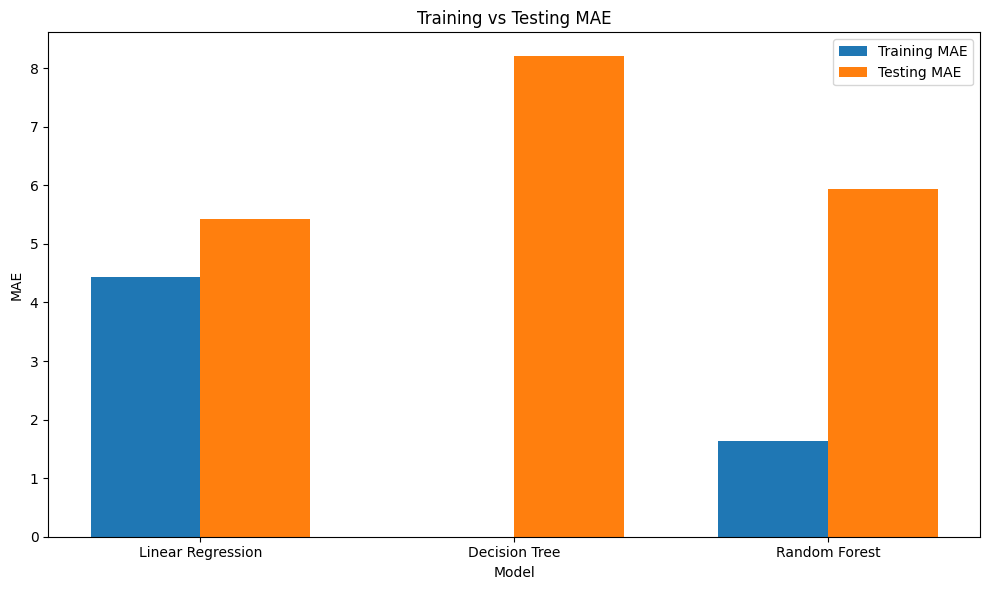

In [121]:
# Visualize training and testing MAE

x = np.arange(len(generalization_results["Model"]))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    generalization_results["Training MAE"],
    width,
    label="Training MAE"
)

plt.bar(
    x + width/2,
    generalization_results["Testing MAE"],
    width,
    label="Testing MAE"
)

plt.xticks(
    x,
    generalization_results["Model"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Training vs Testing MAE")
plt.legend()

plt.tight_layout()
plt.show()

**Observation:**  
The comparison between training and testing performance shows different
levels of generalization across the three models.

Linear Regression has the smallest difference between training and testing
MAE, increasing from 4.4323 during training to 5.4290 during testing. This
indicates comparatively better generalization than the tree-based models.

The Decision Tree shows severe overfitting, with a training MAE of 0.0000
but a testing MAE of 8.2031. Its training R² is 1.0000, while its testing R²
falls to -1.8337, indicating very poor generalization.

The Random Forest reduces the training error compared with the Decision Tree,
but still shows a substantial gap between training and testing performance.
Its training MAE is 1.6384 compared with a testing MAE of 5.9319, while its
training R² of 0.9497 falls to -0.5178 on the testing data.

Overall, Linear Regression demonstrates the best generalization among the
three models, although its negative testing R² indicates that the current
feature set does not adequately explain the variation in unseen demand.

### Best Model Selection

The models are compared based on their performance on the unseen testing
dataset. Since this study focuses on demand prediction, lower MAE and RMSE
and a higher R² score are preferred.

Among the evaluated models, Linear Regression achieved the best testing
performance, with a test MAE of 5.4290, a test RMSE of 6.8054, and a test R²
of -0.2733. It also showed a smaller difference between training and testing
performance compared with the Decision Tree and Random Forest models.

Therefore, Linear Regression is selected as the best-performing model among
the approaches evaluated in this study. However, its negative testing R²
indicates that the current feature set has limitations in explaining the
variation in unseen next-day demand.

The selected model and its limitations are considered in the discussion and
recommendations presented in the following sections.

In [122]:
# Select the best model based on the lowest testing MAE

best_model_row = model_comparison.loc[
    model_comparison["Test MAE"].idxmin()
]

print("Best Model:", best_model_row["Model"])
print("Test MAE:", round(best_model_row["Test MAE"], 4))
print("Test RMSE:", round(best_model_row["Test RMSE"], 4))
print("Test R²:", round(best_model_row["Test R²"], 4))

Best Model: Linear Regression
Test MAE: 5.429
Test RMSE: 6.8054
Test R²: -0.2733


# Model Interpretation

Model interpretation is performed to understand the contribution of the input
features to next-day demand prediction.

Since Linear Regression was selected as the best-performing model, its
coefficients are examined to identify features associated with increases or
decreases in predicted demand.

Feature interpretation helps connect the machine learning results with the
supply chain problem and provides insights that can support demand planning
and inventory management decisions.

### Linear Regression Coefficient Analysis

The coefficients of the Linear Regression model are examined to understand
the direction and relative magnitude of the relationship between the input
features and predicted next-day demand.

A positive coefficient indicates that an increase in the corresponding
feature is associated with an increase in predicted demand, while a negative
coefficient indicates an inverse relationship, assuming other features remain
constant.

For categorical variables that were one-hot encoded, the coefficients
represent the contribution of the corresponding encoded category relative to
the reference category.

In [123]:
# Get feature names from the preprocessing step

feature_names = preprocessor.get_feature_names_out()

# Get Linear Regression coefficients
linear_coefficients = linear_model.coef_

# Create a dataframe of coefficients
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_coefficients
})

# Calculate absolute coefficient magnitude
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

# Sort by strongest absolute coefficient
coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficient_df.head(15).round(4)

,Feature,Coefficient,Absolute_Coefficient
80,remainder__rolling_mean_14,0.7653,0.7653
82,remainder__month,0.2730,0.2730
83,remainder__quarter,-0.1533,0.1533
9,categorical__SKU_ID_SKU_18,0.1332,0.1332
4,categorical__SKU_ID_SKU_13,0.0852,0.0852
39,categorical__SKU_ID_SKU_45,-0.0828,0.0828
68,categorical__Region_West,0.0713,0.0713
31,categorical__SKU_ID_SKU_38,0.0690,0.0690
2,categorical__SKU_ID_SKU_11,0.0681,0.0681
66,categorical__Region_North,-0.0677,0.0677


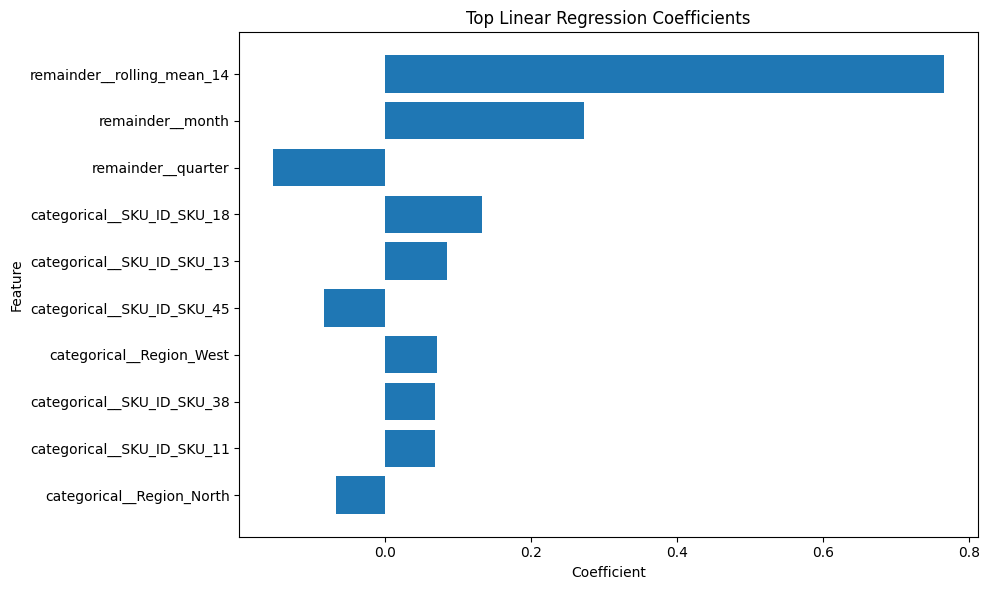

In [124]:
# Select the 10 strongest coefficients

top_coefficients = coefficient_df.head(10).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.title("Top Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Observation:**  
The coefficient analysis shows that the 14-day rolling mean of historical
demand has the strongest positive coefficient (0.7653) among the evaluated
features. This indicates that recent historical demand patterns have an
important positive relationship with the predicted next-day demand.

The month feature also has a positive coefficient of 0.2730, while the
quarter feature has a negative coefficient of -0.1533, indicating that
temporal factors contribute to the model's predictions.

Several SKU-specific coefficients are also present, with SKU_18 showing a
positive coefficient of 0.1332 and SKU_45 showing a negative coefficient of
-0.0828 among the stronger categorical effects.

The coefficient analysis suggests that historical demand patterns and
temporal characteristics are more influential in the Linear Regression model
than several of the other encoded categorical variables. These coefficients
represent model associations and should not be interpreted as proof of
causal relationships.

### Feature Importance Analysis

Feature importance from the Random Forest model is examined to identify the
features that contributed most to its predictions of next-day demand.

Unlike Linear Regression coefficients, feature importance indicates the
relative contribution of each feature to the decisions made by the tree-based
model. Higher importance values indicate that a feature was used more
frequently or effectively by the Random Forest when reducing prediction error.

The analysis provides a complementary interpretation of the machine learning
results and helps identify the most influential demand-related features.

In [126]:
# Get feature importance from the Random Forest model

rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
rf_feature_importance = rf_feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Display the 15 most important features
rf_feature_importance.head(15).round(4)

,Feature,Importance
85,remainder__day_of_year,0.5471
80,remainder__rolling_mean_14,0.0592
82,remainder__month,0.0402
69,remainder__Inventory_Level,0.0346
83,remainder__quarter,0.0335
79,remainder__rolling_mean_7,0.0266
78,remainder__lag_14,0.0252
77,remainder__lag_7,0.0251
76,remainder__lag_1,0.0249
84,remainder__week_of_year,0.0241


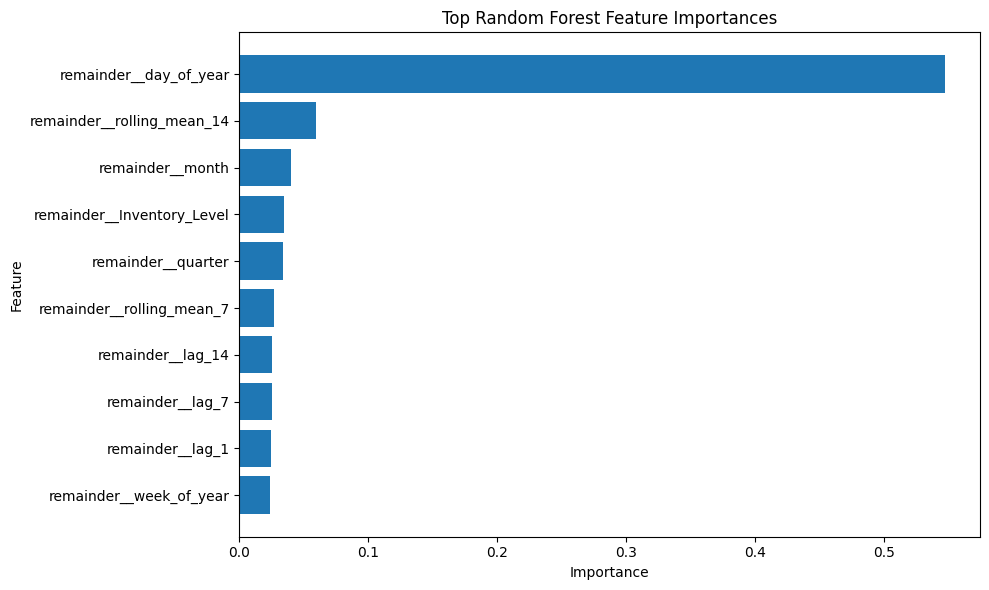

In [127]:
# Plot the top 10 Random Forest feature importances

top_rf_features = rf_feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

**Observation:**  
The Random Forest feature-importance analysis shows that the day of year is
the most influential feature, with an importance value of 0.5471. This is
substantially higher than the other features, indicating that the model relies
strongly on the position of the observation within the year when predicting
next-day demand.

The 14-day rolling mean is the second most important feature with an
importance of 0.0592, followed by month (0.0402), inventory level (0.0346),
and quarter (0.0335). Other historical demand features, including the
7-day and 14-day lag variables and rolling mean, also contribute to the
model's predictions.

The importance of temporal and historical-demand features suggests that
seasonal patterns and recent demand history are important factors for demand
prediction in this dataset.

Feature importance represents the model's predictive reliance on a feature
and does not establish a causal relationship between the feature and demand.

### Key Interpretation Summary

The model interpretation results provide complementary insights into the factors
associated with next-day demand prediction.

The Linear Regression analysis indicates that the 14-day rolling mean of
historical demand has the strongest coefficient, followed by temporal
features such as month and quarter. Several SKU-specific and regional
coefficients also contribute to the model's predictions.

The Random Forest analysis identifies day of year as the most important
feature, followed by the 14-day rolling mean, month, inventory level, quarter,
and other historical demand features. This indicates that temporal patterns
and recent demand history play an important role in the prediction process.

Overall, both interpretation approaches highlight the importance of
historical demand and temporal information. These findings can help support
demand planning by emphasizing the value of historical sales patterns and
time-based demand trends when estimating future product requirements.

The identified relationships represent predictive associations within the
dataset and should not be interpreted as causal effects.

# Discussion

The analysis examined the factors associated with next-day demand and evaluated
multiple regression approaches for demand prediction. The results provide
insights into temporal demand patterns, promotional effects, and the
performance and limitations of different machine learning models.

The exploratory analysis showed clear variation in average demand over time,
with demand increasing during the early part of the year before declining and
then recovering toward the end of the year. In contrast, average demand was
relatively similar across SKUs, warehouses, and regions.

Promotional observations showed noticeably higher average units sold than
non-promotional observations. The statistical analysis confirmed that this
difference was statistically significant. However, statistical significance
does not by itself establish that promotions caused the increase in demand.

The statistical correlation analysis also showed that most operational and
pricing variables had weak linear relationships with demand. Inventory level
showed a weak negative relationship, while order quantity and promotion status
showed statistically significant relationships due to the large sample size.
The strength of these relationships should therefore be considered alongside
their correlation magnitude.

Among the evaluated predictive approaches, Linear Regression achieved the
best testing performance, with a test MAE of 5.4290 and RMSE of 6.8054.
However, its testing R² was -0.2733, indicating that the current feature set
does not adequately explain the variation in unseen next-day demand.

The Decision Tree showed severe overfitting, achieving an R² of 1.0000 on
the training data but -1.8337 on the testing data. The Random Forest reduced
the training error compared with the Decision Tree but still showed a large
difference between training and testing performance. These results indicate
that increasing model complexity did not improve generalization for the
current feature set.

Model interpretation further highlighted the importance of temporal and
historical demand features. The Linear Regression model assigned its
strongest coefficient to the 14-day rolling mean, while the Random Forest
identified day of year as its most important feature. This suggests that
recent demand history and temporal patterns are useful for understanding
demand variation in the dataset.

Overall, the findings suggest that demand forecasting can benefit from
historical and time-based information, but the current models have limited
predictive performance on the unseen test period. The results therefore
provide a useful baseline for future improvements in feature engineering,
model selection, and demand forecasting methodology.

### Key Findings

The main findings from the exploratory analysis, statistical analysis, and
machine learning evaluation are summarized below:

1. **Temporal demand variation:**  
   Average daily demand shows clear variation throughout the year, with
   demand increasing during the early months, reaching higher levels around
   spring, declining through the middle of the year, and recovering toward
   the end of the year.

2. **Similar demand across operational groups:**  
   Average units sold are relatively similar across the different SKUs,
   warehouses, and regions. This indicates that these categorical groupings
   do not show large differences in average demand in the dataset.

3. **Promotion and demand:**  
   Observations with promotions have a substantially higher average demand
   than observations without promotions. The independent t-test produced a
   statistically significant result, indicating a significant difference in
   mean demand between the two groups.

4. **Weak relationships with most operational variables:**  
   Inventory level, supplier lead time, reorder point, unit cost, and unit
   price show weak linear relationships with units sold. Although some
   relationships are statistically significant, their correlation
   magnitudes are small.

5. **Historical and temporal features are important:**  
   The model interpretation results highlight historical demand and
   time-related features as important predictors. The 14-day rolling mean
   had the strongest Linear Regression coefficient, while day of year was
   the most important feature in the Random Forest model.

6. **Linear Regression generalizes best among the evaluated models:**  
   Linear Regression achieved the lowest testing MAE (5.4290) and RMSE
   (6.8054) among the evaluated approaches and therefore performed better
   than the persistence baseline, Decision Tree, and Random Forest on the
   unseen testing period.

7. **Tree-based models showed overfitting:**  
   The Decision Tree achieved perfect training performance but substantially
   poorer testing performance. The Random Forest also showed a considerable
   difference between training and testing performance. This demonstrates
   that greater model complexity did not improve generalization for the
   current feature set.

8. **Current predictive performance remains limited:**  
   Although Linear Regression was the best-performing model, its testing
   R² of -0.2733 indicates that the current feature set does not adequately
   explain the variation in unseen next-day demand. Therefore, the results
   should be treated as a baseline rather than a highly accurate forecasting
   solution.

### Business Implications

The findings have several potential implications for supply chain and
inventory management.

1. **Demand planning:**  
   The observed temporal patterns indicate that demand planning should
   consider seasonal and time-based variations rather than relying only on
   overall average demand.

2. **Promotion planning:**  
   The higher average demand observed during promotional periods suggests
   that promotional activities should be considered when preparing inventory
   and supply plans.

3. **Historical demand monitoring:**  
   The importance of rolling demand measures indicates that recent sales
   history can provide useful information for anticipating future demand.
   Maintaining reliable historical sales records can therefore support
   demand planning activities.

4. **Inventory planning:**  
   Inventory level was identified as an influential feature in the Random
   Forest model, although its direct linear relationship with demand was
   weak. Inventory decisions should therefore consider demand history and
   other operational factors together rather than relying on inventory
   levels alone.

5. **Model selection:**  
   The results demonstrate that a more complex model does not necessarily
   provide better business predictions. In this study, Linear Regression
   generalized better than the tree-based models on the unseen testing
   period.

6. **Need for improved forecasting:**  
   Since the selected model achieved a negative testing R², the current
   forecasting approach should not be treated as a production-ready demand
   forecasting system. Additional historical data, improved feature
   engineering, and further model development would be required before using
   the predictions for important inventory decisions.

### Limitations of the Study

The following limitations should be considered when interpreting the results
of this study:

1. **Limited time period:**  
   The dataset contains approximately one year of observations. Therefore,
   the models have limited information for learning recurring annual
   seasonal patterns across multiple years.

2. **Limited predictive performance:**  
   Although Linear Regression performed best among the evaluated models, its
   testing R² score was -0.2733. This indicates that the current feature set
   and modeling approach do not adequately explain the variation in unseen
   next-day demand.

3. **Model overfitting:**  
   The Decision Tree and Random Forest models showed substantially better
   performance on training data than on testing data. This indicates
   overfitting and limited generalization to the unseen test period.

4. **Limited variation in some variables:**  
   Average demand was highly similar across SKUs, warehouses, and regions.
   In addition, `Stockout_Flag` contained only one value in the dataset and
   therefore could not provide useful predictive variation.

5. **Potential leakage in the provided forecast variable:**  
   `Demand_Forecast` showed a very strong relationship with `Units_Sold`.
   Because it closely tracks observed demand, it was excluded from the
   predictive feature set to reduce the risk of target leakage.

6. **Synthetic or limited dataset characteristics:**  
   The findings are specific to the provided dataset and may not represent
   the behavior of a real-world supply chain with more complex demand,
   supplier, inventory, and market conditions.

7. **Limited causal interpretation:**  
   The statistical and machine learning analyses identify associations and
   predictive relationships. They do not establish that variables such as
   promotions, inventory, or pricing directly cause changes in demand.

# Conclusion & Recommendations

## Conclusion

This study investigated a data-driven approach to inventory management and next-day demand forecasting using SKU-level, warehouse-level, supplier-level, operational, and promotional information. The analysis followed a complete workflow involving data cleaning, feature engineering, exploratory data analysis, statistical testing, machine learning, model evaluation, and interpretation.

The exploratory and statistical analysis showed that demand varies over time and that promotional periods are associated with higher sales. Inventory level and order quantity showed statistically significant but relatively weak relationships with demand, while supplier lead time, reorder point, unit cost, and unit price showed limited linear association with actual sales in the given dataset. Regional demand differences were also not statistically significant.

For forecasting, the study predicted next-day units sold using historical demand patterns, temporal features, operational variables, commercial variables, and categorical information. A persistence baseline, Linear Regression, Decision Tree, and Random Forest were evaluated using a chronological train-test split. Among the tested models, Linear Regression achieved the best test performance, with a test MAE of 5.4290, RMSE of 6.8054, and R² of -0.2733.

However, the negative test R² indicates that the forecasting performance is still limited and that the current feature set does not fully capture the variation in next-day demand. The Decision Tree and Random Forest models also showed clear signs of overfitting, with substantially better training performance than testing performance.

Overall, the study demonstrates how data analysis and machine learning can support supply chain decision-making, while also highlighting the importance of careful feature selection, leakage prevention, chronological validation, and realistic evaluation. The results provide a useful baseline for future improvements in demand forecasting and inventory planning.

## Supply Chain Recommendations

Based on the findings of this study, the following recommendations can be considered for supply chain and inventory management:

1. **Use historical demand for planning:** Recent demand patterns and rolling averages can be incorporated into daily inventory and replenishment decisions.

2. **Consider promotional periods:** Since promotional periods were associated with higher average sales, inventory and replenishment plans should account for expected increases in demand during promotions.

3. **Monitor inventory levels:** Although the relationship between inventory level and demand was weak, inventory availability remains important for avoiding shortages and supporting continuous sales.

4. **Use data-driven replenishment decisions:** Order quantities and reorder decisions can be supported by historical demand patterns rather than relying only on fixed assumptions.

5. **Prefer models based on realistic validation:** The Linear Regression model performed better on unseen chronological data than the tree-based models evaluated in this study. Model selection should therefore prioritize test performance rather than training accuracy.

6. **Improve forecasting before operational deployment:** The current model should be treated as a baseline rather than a production-ready forecasting system because its test R² is negative and it underpredicts higher demand levels.

7. **Collect richer supply chain information:** Additional variables such as holidays, weather, marketing intensity, actual stockout events, supplier reliability, delivery delays, and longer historical demand records could improve future forecasting performance.

## Future Enhancements

The study can be extended in several ways to improve forecasting accuracy and practical usefulness:

1. **Longer historical data:** Using multiple years of data would allow the models to learn recurring seasonal and yearly demand patterns more reliably.

2. **Additional external factors:** Holidays, weather conditions, local events, economic indicators, and marketing information could be incorporated to explain demand fluctuations.

3. **Advanced forecasting models:** Time-series and ensemble approaches such as Gradient Boosting, XGBoost, LightGBM, or dedicated forecasting models could be evaluated against the current baseline models.

4. **Hyperparameter tuning:** Systematic hyperparameter optimization could be performed to improve model performance while controlling overfitting.

5. **Improved validation strategy:** Rolling or expanding-window time-series validation can provide a more robust estimate of model performance across different periods.

6. **Better inventory optimization:** Future work can connect demand forecasts with reorder points, safety stock, lead times, and order quantities to develop an integrated inventory optimization system.

7. **Explainable forecasting:** Feature importance and explainability techniques can be extended to help supply chain managers understand the factors influencing individual demand predictions.

8. **Deployment as a decision-support system:** The final forecasting model could be integrated into a dashboard that displays predicted demand, inventory status, promotional effects, and replenishment recommendations.

## Final Summary

The project demonstrates a complete data science workflow for supply chain demand analysis and forecasting. The analysis identified important demand patterns, tested relationships statistically, compared multiple forecasting approaches, and evaluated their ability to generalize to future observations.

The results show that machine learning can provide useful analytical support for supply chain planning, but model performance depends strongly on the quality and availability of relevant demand-driving information. The Linear Regression model provided the strongest performance among the evaluated approaches, while the overfitting observed in tree-based models highlights the need for careful model validation.

The findings therefore provide a baseline framework that can be improved with richer data, stronger forecasting methods, and integration with inventory optimization techniques.